# Underwater image enhancement (UIEB) with the WF-Diff architecture

* **Model**: WF-Diff (*Wavelet-based Fourier Information Interaction with Frequency Diffusion Adjustment for Underwater Image Restoration*, CVPR 2024) from `ChenzhaoNju/WF-Diff`, architecture unchanged (Section 1). `WfDiffx2` = WFI2-net (`DFTHL1`) → Haar DWT → `CFC` → two Gaussian-diffusion denoisers (one for the LL band, one for the three high-frequency bands). 100.55 M parameters.
* **Training recipe**: same data pipeline, split, augmentation, optimiser (Adam), scheduler (ReduceLROnPlateau) and early stopping as the other models of this series. The **loss is the one exception**: WF-Diff has seven outputs and cannot be trained with L1 + SSIM on a single image, so the notebook uses the repository's five-term objective (Section 2).
* **Training loop** (Section 4) follows `ASRD_U_Mamba.ipynb`: after every epoch it prints the loss and all 4 metrics (PSNR, SSIM, LPIPS, UIQM) for train and validation, writes one CSV row, keeps **only the single best model** (highest validation PSNR) and stops early after `PATIENCE` epochs without improvement. There are no checkpoints and no resume.

What is different from a single-output model such as WaterNet:

| | WF-Diff |
|---|---|
| training forward | `model(I, J)` returns 7 tensors: preliminary image `x_`, true / predicted noise of both denoisers, `AA`, `HH` |
| **train** metrics | measured on the **preliminary** image `x_` (the final image needs a 10-step DDIM sampling pass per batch), so they are *not* directly comparable to the val / test numbers |
| val / test metrics | full WF-Diff inference: `x_` + DDIM-sampled LL / high-frequency residuals, as in the repository's `WfdiffModel.test()`; 8-bit quantised like every other model |
| val "loss" | L1(final image, GT). The diffusion terms need a noise target, which does not exist at inference |
| inference | one image at a time (see the note in Section 1) |
| precision | float32; no AMP and no `torch.compile` (FFT / complex ops, in-place wavelet synthesis, python-side DDIM loop) |

Files written under `Dehaze/`:

| file | content |
|---|---|
| `logs/training_log.csv` | one row per epoch: LR, train loss + PSNR/SSIM/LPIPS/UIQM, val loss + PSNR/SSIM/LPIPS/UIQM, timings, throughput, GPU memory, `is_best` |
| `logs/metrics_test.csv` | final test metrics |
| `logs/timing_summary.csv` | training time, inference latency / FPS, parameters, MACs |
| `logs/comparison_metrics.csv` | per-image metrics for the qualitative comparison |
| `models/data_split.csv` | train/val/test file lists |
| `models/best_model_wfdiff.pth` | best model (`state_dict`, selected by validation PSNR) |


# Imports

In [1]:
# %pip install -q lpips thop scikit-image opencv-python scipy einops   # uncomment on a fresh environment
import sys
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import time
import csv
import copy
import math
import random
import datetime
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import lpips  # pip install lpips


e:\under_water_dehazing\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = os.path.abspath(".")
DATASET_ROOT = os.path.join(PROJECT_ROOT, "dataset")
RAW_DIR = os.path.join(DATASET_ROOT, "raw-890")          # degraded inputs
REF_DIR = os.path.join(DATASET_ROOT, "reference-890")    # clean reference images (same file names)
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "models")
LOG_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "logs")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "comparison_outputs")
for d in [MODEL_SAVE_DIR, LOG_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- data / optimisation
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-5
LR_PATIENCE = 5
LR_FACTOR = 0.5
LR_MIN = 1e-6

# ---- loss weights: the five terms of the repository's objective (all 1.0 in options/train/train_Wfdiff.yml)
LOSS_W_REC = 1.0       # L1(x_, GT)                      preliminary image from WFI2-net
LOSS_W_AMP = 1.0       # AFFT(AA, GT_LL)                 L1 between rFFT amplitude spectra, LL sub-band
LOSS_W_HIGH = 1.0      # MSE(HH, GT_high)                high-frequency sub-bands
LOSS_W_DIFF = 1.0      # L1(noise, predicted noise)      applied to both denoisers (LL and high-frequency)

# ---- WF-Diff configuration: the `network_g` block of options/train/train_Wfdiff.yml, architecture unchanged.
# (local_ensemble / feat_unfold / cell_decode / ppg_input_channels are also in that yml, but WfDiffx2 accepts and ignores them.)
WF_IN_CHANNEL = 6          # denoiser input = 3 (condition: sub-band of the preliminary image) + 3 (noisy residual)
WF_OUT_CHANNEL = 3
WF_INNER_CHANNEL = 48
WF_NORM_GROUPS = 24
WF_WITH_TIME_EMB = True
WF_SAMPLE_PROC = "ddim"
WF_SCHEDULE_OPT = dict(schedule="linear", n_timestep=2000, linear_start=1e-6, linear_end=1e-2)

# ---- data split (UIEB has no official split)
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
TRAIN_UIQM = False                 # disabled during training: UIQM is a slow CPU/NumPy metric
                                   # (validation/test UIQM remain enabled)

# ---- training loop (same scheme as ASRD_U_Mamba.ipynb)
PATIENCE = 25              # early stopping: stop after this many epochs without a new best val PSNR
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_model_wfdiff.pth")   # the only model file written during training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- hybrid / mixed precision ----------------------------------------------
# Keep model weights in FP32. AMP uses FP16 for eligible CUDA ops, while
# sensitive FFT/complex operations are explicitly kept in FP32 below.
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16

# ---- speed / memory optimizations -------------------------------------------
# Validation runs the expensive 10-step DDIM sampler, so during experiments
# validate every N epochs instead of every epoch.
VAL_EVERY = 3

# Training PSNR/SSIM are metrics only; they are not part of the loss.
# Compute them on a subset of training batches to avoid unnecessary synchronization.
TRAIN_METRICS_EVERY = 4

# Activation checkpointing trades extra recomputation for substantially lower
# activation memory. This can improve effective throughput if the GPU was memory-bound.
USE_GRAD_CHECKPOINTING = True

# ---------- speed knobs -------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True   # auto-tune conv algorithms (fixed input size)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_num_threads(4)  # cap CPU threads so workers don't fight each other

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# WF-Diff works on Haar sub-bands (IMG_SIZE / 2) which WFI2-net and the denoiser UNet down-sample twice more
# (pixel-unshuffle), so IMG_SIZE must be a multiple of 8.
assert IMG_SIZE % 8 == 0, "IMG_SIZE must be a multiple of 8"

for p in [RAW_DIR, REF_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory: {p}")

print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print(f"Hybrid AMP: {USE_AMP} | autocast dtype: {AMP_DTYPE}")
print("Raw images:", len(os.listdir(RAW_DIR)), "Reference images:", len(os.listdir(REF_DIR)))


Device: cuda (NVIDIA GeForce RTX 3060)
Hybrid AMP: True | autocast dtype: torch.float16
Raw images: 890 Reference images: 890


## Dataset Loader

In [3]:
# ============================================================================
# Helper utilities  (np_to_tensor, tensor_to_uint8, compute_uiqm,
#                    ssim_torch, sync, lpips_fn)
# ============================================================================
import torch, numpy as np
import lpips as _lpips_module

# ---------- tensor <-> numpy helpers ----------------------------------------

def np_to_tensor(img_uint8):
    """uint8 HxWx3 numpy array -> float32 3xHxW tensor in [0,1]."""
    return torch.from_numpy(img_uint8.astype(np.float32) / 255.0).permute(2, 0, 1)


def tensor_to_uint8(t):
    """3xHxW (or 1x3xHxW) float tensor in [0,1] -> uint8 HxWx3 numpy array."""
    if t.dim() == 4:
        t = t.squeeze(0)
    return (t.detach().clamp(0, 1).permute(1, 2, 0).cpu().float().numpy() * 255.0).round().astype(np.uint8)


# ---------- CUDA sync helper ------------------------------------------------

def sync():
    """Block until all CUDA kernels complete (no-op on CPU)."""
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# ---------- SSIM (differentiable, batched) ----------------------------------

def _gaussian_kernel_1d(size=11, sigma=1.5):
    x = torch.arange(size, dtype=torch.float32) - size // 2
    k = torch.exp(-x ** 2 / (2 * sigma ** 2))
    return k / k.sum()


def _ssim_kernel(size=11, sigma=1.5):
    k1d = _gaussian_kernel_1d(size, sigma)
    k2d = k1d.unsqueeze(1) * k1d.unsqueeze(0)        # (size, size)
    return k2d.unsqueeze(0).unsqueeze(0)              # (1, 1, size, size)


_SSIM_WIN = None        # cached kernel (keyed by device + dtype)
_SSIM_WIN_KEY = None


def ssim_torch(pred, target, size=11, sigma=1.5, C1=0.01**2, C2=0.03**2):
    """Per-image differentiable SSIM.  Returns shape (B,).
    Always computed in float32: the model output can be float16 (AMP) while the target is float32, and
    variance = E[x^2] - E[x]^2 is numerically unreliable in float16."""
    global _SSIM_WIN, _SSIM_WIN_KEY
    pred, target = pred.float(), target.float()
    key = (pred.device, torch.float32)
    if _SSIM_WIN is None or _SSIM_WIN_KEY != key:
        _SSIM_WIN = _ssim_kernel(size, sigma).to(pred.device, dtype=torch.float32)
        _SSIM_WIN_KEY = key
    B, C, H, W = pred.shape
    # Treat all channels independently then average
    p = pred.reshape(B * C, 1, H, W)
    t = target.reshape(B * C, 1, H, W)
    pad = size // 2
    mu_p  = torch.nn.functional.conv2d(p, _SSIM_WIN, padding=pad)
    mu_t  = torch.nn.functional.conv2d(t, _SSIM_WIN, padding=pad)
    mu_p2 = mu_p ** 2
    mu_t2 = mu_t ** 2
    mu_pt = mu_p * mu_t
    sig_p2 = torch.nn.functional.conv2d(p * p, _SSIM_WIN, padding=pad) - mu_p2
    sig_t2 = torch.nn.functional.conv2d(t * t, _SSIM_WIN, padding=pad) - mu_t2
    sig_pt = torch.nn.functional.conv2d(p * t, _SSIM_WIN, padding=pad) - mu_pt
    num = (2 * mu_pt + C1) * (2 * sig_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sig_p2 + sig_t2 + C2)
    ssim_map = num / den.clamp_min(1e-8)
    ssim_per_channel = ssim_map.reshape(B, C, H, W).mean(dim=(1, 2, 3))   # (B,)
    return ssim_per_channel


# ---------- LPIPS (evaluation metric only -- not part of the loss) -----------------------------

lpips_fn = _lpips_module.LPIPS(net="alex", verbose=False).to(DEVICE)


# ---------- UIQM (Underwater Image Quality Measure) ------------------------
# Ref: Panetta et al. 2016.  Pure-numpy implementation, runs on CPU.

def _uicm(img_f32):
    """Chroma measure."""
    rg = img_f32[:, :, 0] - img_f32[:, :, 1]
    yb = 0.5 * (img_f32[:, :, 0] + img_f32[:, :, 1]) - img_f32[:, :, 2]
    def _stats(x):
        mu = x.mean(); sigma = x.std()
        # asymmetric alpha-trimmed mean
        flat = x.flatten(); flat.sort()
        n = len(flat); lo, hi = int(0.1 * n), int(0.9 * n)
        alpha_mu = flat[lo:hi].mean() if hi > lo else mu
        return alpha_mu, sigma
    mu_rg, sig_rg = _stats(rg)
    mu_yb, sig_yb = _stats(yb)
    return -0.0268 * np.sqrt(mu_rg**2 + mu_yb**2) + 0.1586 * np.sqrt(sig_rg**2 + sig_yb**2)


def _uism(img_uint8):
    """Sharpness measure (Sobel)."""
    from scipy import ndimage
    score = 0.0
    weights = [0.299, 0.587, 0.114]
    for ch, w in enumerate(weights):
        chan = img_uint8[:, :, ch].astype(np.float32)
        sx = ndimage.sobel(chan, axis=0); sy = ndimage.sobel(chan, axis=1)
        edges = np.hypot(sx, sy)
        # EME (Enhancement Measure Estimation) with k=8 blocks
        h, wd = edges.shape
        bh, bw = max(h // 8, 1), max(wd // 8, 1)
        eme = 0.0; count = 0
        for r in range(0, h, bh):
            for c in range(0, wd, bw):
                blk = edges[r:r+bh, c:c+bw]
                mx = blk.max(); mn = blk.min()
                if mx > 0 and mn > 0:
                    eme += np.log(mx / (mn + 1e-5))
                    count += 1
        score += w * (2.0 / max(count, 1)) * eme
    return score


def _uiconm(img_f32):
    """Contrast measure."""
    from scipy import ndimage
    gray = 0.299 * img_f32[:, :, 0] + 0.587 * img_f32[:, :, 1] + 0.114 * img_f32[:, :, 2]
    ambe = np.abs(ndimage.uniform_filter(gray, size=8) - gray.mean())
    return np.log1p(ambe.mean())


def compute_uiqm(img_uint8):
    """UIQM score for a uint8 HxWx3 numpy array."""
    img_f32 = img_uint8.astype(np.float32) / 255.0
    c1, c2, c3 = 0.0282, 0.2953, 3.5753
    return c1 * _uicm(img_f32) + c2 * _uism(img_uint8) + c3 * _uiconm(img_f32)

print("Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)")


e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)


In [4]:
class UIEBDataset(Dataset):
    """Returns (degraded image I, reference image J), both 3xHxW float32 in [0,1].
    Augmentation uses fast numpy flips + optional rotation; the heavy rotation is
    removed (flip-only is ~10x faster and sufficient for regularisation).
    """
    def __init__(self, pairs, img_size=256, train=False, cache_in_memory=True):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train
        self.cache_in_memory = cache_in_memory
        if self.cache_in_memory:
            # Pre-load & resize into contiguous uint8 arrays → eliminates disk I/O per batch
            self.cached_pairs = [
                (self._load(raw_p), self._load(ref_p)) for raw_p, ref_p in pairs
            ]

    def __len__(self):
        return len(self.pairs)

    def _load(self, path):
        with Image.open(path) as im:
            img = np.array(im.convert("RGB"))
        return cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

    def _augment(self, raw, ref):
        # ---- fast numpy augmentations (no warpAffine / no rotation) ----
        if random.random() < 0.5:
            raw, ref = np.fliplr(raw).copy(), np.fliplr(ref).copy()   # horizontal flip
        if random.random() < 0.5:
            raw, ref = np.flipud(raw).copy(), np.flipud(ref).copy()   # vertical flip
        # brightness jitter on input only (cheap scalar multiply)
        factor = random.uniform(0.85, 1.15)
        raw = np.clip(raw.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        return raw, ref

    def __getitem__(self, idx):
        if self.cache_in_memory:
            raw, ref = self.cached_pairs[idx]
            raw, ref = raw.copy(), ref.copy()
        else:
            raw_path, ref_path = self.pairs[idx]
            raw, ref = self._load(raw_path), self._load(ref_path)
        if self.train:
            raw, ref = self._augment(raw, ref)
        return np_to_tensor(raw), np_to_tensor(ref)


# 1. Base Model

The WF-Diff architecture, extracted programmatically from the repository (`basicsr/archs/wfdiffx2_arch.py` and `Padiff_arch/{wavelet, dft_arch, cfc_arch, diffx2_arch, unetx2_arch}.py`, `unet_block/{trans_block_eca, cross_attention_module}.py`). First cell: building blocks. Second cell: WFI2-net, CFC, denoiser UNet, Gaussian diffusion and the top-level `WfDiffx2`. Do not edit these two cells.

**Only mechanical changes were made** (all attribute names are untouched, so `state_dict` keys are identical to the repository's and its pretrained checkpoints load with `strict=True`):

* BasicSR registry decorators removed, and the import of `Padiff_arch.inr_arch` dropped: that file does not exist in the repository and `INR` is never used.
* Two *different* classes share a name across repository files and were renamed: `trans_block_eca.FeedForward` → `FeedForward_UNet`, `dft_arch.FeedForward` → `FeedForward_DFT`, `cross_attention_module.CFC` → `CFC_UNet` (`cfc_arch.CFC` keeps the name `CFC`). Byte-identical duplicates (`DWT`, `IWT`, `Depth_conv`, `LayerNorm`, ...) are defined once.
* `WfDiffx2` passed the literal string `'sample_proc'` instead of its argument; the value is stored but never read, so it now passes the argument. `gt != None` became `gt is not None` (same result).
* Code that `WfDiffx2` never calls is not included (`PPG`/`TNet`, `DFT`, `DFTHL`, `Wide_Transformer`, ...). Layers that are constructed but whose call is commented out in the repository (e.g. `Encoder.block4`, `DFTHL1.encoder_level3`) are **kept**, so the parameter count and checkpoints match.

**Known quirk of the repository's sampler, kept as is.** `GaussianDiffusionx2.p_sample_loop` ends with `return ret_img[-1], None`, i.e. it returns only the *last element of the batch dimension*. With a batch of several images, one image's residual would be added to all of them, and for the high-frequency branch (HL, LH, HH stacked in the batch dimension) only the HH residual is used for all three bands. The repository's tester always uses batch size 1, so I reproduce exactly that: `wfdiff_infer` (next cell group) runs the images one at a time. A batched sampler would be faster but would not be the repository's model.


In [5]:
# ============================================================================
# WF-Diff  (Zhao et al., CVPR 2024)  --  github.com/ChenzhaoNju/WF-Diff
# Cell 1/2 : building blocks, copied from the repository's basicsr/archs/ sources.
#   Only mechanical changes (see the notes in the markdown cell above):
#     * BasicSR registry decorators dropped
#     * two different classes that share a name across repo files are renamed
#         trans_block_eca.FeedForward      -> FeedForward_UNet
#         dft_arch.FeedForward             -> FeedForward_DFT
#         unet_block/cross_attention_module.CFC -> CFC_UNet   (cfc_arch.CFC keeps the name CFC)
#     * identical duplicates (DWT/IWT, Depth_conv, LayerNorm, ...) are defined once
#   Attribute names are untouched, so state_dict keys are identical to the repository's.
# ============================================================================
import numbers
from functools import partial
from inspect import isfunction
from einops import rearrange

# ----------------------------------------------------------------------------
# Haar wavelet  (Padiff_arch/wavelet.py)
# ----------------------------------------------------------------------------

def dwt_init(x):

    x01 = x[:, :, 0::2, :] / 2
    x02 = x[:, :, 1::2, :] / 2
    x1 = x01[:, :, :, 0::2]
    x2 = x02[:, :, :, 0::2]
    x3 = x01[:, :, :, 1::2]
    x4 = x02[:, :, :, 1::2]
    x_LL = x1 + x2 + x3 + x4
    x_HL = -x1 - x2 + x3 + x4
    x_LH = -x1 + x2 - x3 + x4
    x_HH = x1 - x2 - x3 + x4

    return torch.cat((x_LL, x_HL, x_LH, x_HH), 0)


def iwt_init(x):
    r = 2
    in_batch, in_channel, in_height, in_width = x.size()
    out_batch, out_channel, out_height, out_width = int(in_batch/(r**2)),in_channel, r * in_height, r * in_width
    x1 = x[0:out_batch, :, :] / 2
    x2 = x[out_batch:out_batch * 2, :, :, :] / 2
    x3 = x[out_batch * 2:out_batch * 3, :, :, :] / 2
    x4 = x[out_batch * 3:out_batch * 4, :, :, :] / 2

    h = torch.zeros([out_batch, out_channel, out_height,
                     out_width]).float().to(x.device)

    h[:, :, 0::2, 0::2] = x1 - x2 - x3 + x4
    h[:, :, 1::2, 0::2] = x1 - x2 + x3 - x4
    h[:, :, 0::2, 1::2] = x1 + x2 - x3 - x4
    h[:, :, 1::2, 1::2] = x1 + x2 + x3 + x4

    return h


class DWT(nn.Module):
    def __init__(self):
        super(DWT, self).__init__()
        self.requires_grad = False  # 信号处理，非卷积运算，不需要进行梯度求导

    def forward(self, x):
        return dwt_init(x)


class IWT(nn.Module):
    def __init__(self):
        super(IWT, self).__init__()
        self.requires_grad = False

    def forward(self, x):
        return iwt_init(x)


# ----------------------------------------------------------------------------
# Shared blocks  (Depth_conv / LayerNorm are byte-identical in the repo's files)
# ----------------------------------------------------------------------------

class Depth_conv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Depth_conv, self).__init__()
        self.depth_conv = nn.Conv2d(
            in_channels=in_ch,
            out_channels=in_ch,
            kernel_size=(3, 3),
            stride=(1, 1),
            padding=1,
            groups=in_ch
        )
        self.point_conv = nn.Conv2d(
            in_channels=in_ch,
            out_channels=out_ch,
            kernel_size=(1, 1),
            stride=(1, 1),
            padding=0,
            groups=1
        )

    def forward(self, input):
        out = self.depth_conv(input)
        out = self.point_conv(out)
        return out


def to_3d(x):
    return rearrange(x, 'b c h w -> b (h w) c')


def to_4d(x, h, w):
    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)


class BiasFree_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super(BiasFree_LayerNorm, self).__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)

        assert len(normalized_shape) == 1

        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.normalized_shape = normalized_shape

    def forward(self, x):
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return x / torch.sqrt(sigma + 1e-5) * self.weight


class WithBias_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super(WithBias_LayerNorm, self).__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)

        assert len(normalized_shape) == 1

        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.normalized_shape = normalized_shape

    def forward(self, x):
        mu = x.mean(-1, keepdim=True)
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return (x - mu) / torch.sqrt(sigma + 1e-5) * self.weight + self.bias


class LayerNorm(nn.Module):
    def __init__(self, dim, LayerNorm_type):
        super(LayerNorm, self).__init__()
        if LayerNorm_type == 'BiasFree':
            self.body = BiasFree_LayerNorm(dim)
        else:
            self.body = WithBias_LayerNorm(dim)

    def forward(self, x):
        h, w = x.shape[-2:]
        return to_4d(self.body(to_3d(x)), h, w)


# ----------------------------------------------------------------------------
# Denoiser blocks  (Padiff_arch/unet_block/trans_block_eca.py, cross_attention_module.py, unetx2_arch.py)
# ----------------------------------------------------------------------------

class FeedForward_UNet(nn.Module):
    def __init__(self, dim, ffn_expansion_factor, bias):
        super(FeedForward_UNet, self).__init__()

        self.x1_Conv1 = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.x1_Conv5 = nn.Conv2d(dim, dim, kernel_size=5,padding=2, bias=bias)
        self.x2_Conv1 = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.x2_Conv5 = nn.Conv2d(dim, dim, kernel_size=5,padding=2, bias=bias)
        self.x3_Conv1 = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.x3_Conv5 = nn.Conv2d(dim, dim, kernel_size=5,padding=2, bias=bias)
        self.x4_Conv1 = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.x4_Conv5 = nn.Conv2d(dim, dim, kernel_size=5,padding=2, bias=bias)
        self.x5_Conv1 = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.x5_Conv5 = nn.Conv2d(dim, dim, kernel_size=5,padding=2, bias=bias)

        self.outCon = nn.Conv2d(2*dim, dim, kernel_size=1, bias=bias)

    def forward(self, x):

        x1 = self.x1_Conv5(self.x1_Conv1(x))
        x2 = self.x2_Conv5(self.x2_Conv1(x))
        x3 = self.x3_Conv5(self.x3_Conv1(x))

        x1 = x2 + self.x4_Conv5(self.x4_Conv1(F.gelu(x1) * x2))
        x3 = x2 + self.x5_Conv5(self.x5_Conv1(F.gelu(x3) * x2))

        return self.outCon(torch.concat([x1,x3],dim=1))


class PA_MSA(nn.Module):
    def __init__(self, dim, num_heads, bias,t_dim = 3):
        super(PA_MSA, self).__init__()
        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.q = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.q_dwconv = nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, groups=dim, bias=bias)
        
        self.q_T = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.q_dwconv_T = nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, groups=dim, bias=bias)
        self.q_concat = nn.Conv2d(2*dim, dim, kernel_size=1, bias=bias)
        
        self.k_T = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.k_dwconv_T = nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, groups=dim, bias=bias)
        self.k_concat = nn.Conv2d(2*dim, dim, kernel_size=1, bias=bias)

        self.k = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.k_dwconv = nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, groups=dim, bias=bias)
        self.v = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)
        self.v_dwconv = nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1, groups=dim, bias=bias)


    def forward(self, x):
        b, c, h, w = x.shape

        q = self.q_dwconv(self.q(x))
        
        k = self.k_dwconv(self.k(x))
       
        v = self.v_dwconv(self.v(x))

        q = rearrange(q, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
       
        k = rearrange(k, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
       
        v = rearrange(v, 'b (head c) h w -> b head c (h w)', head=self.num_heads)

        

        q = torch.nn.functional.normalize(q, dim=-1)
        k = torch.nn.functional.normalize(k, dim=-1)

        attn = (q @ k.transpose(-2, -1)) * self.temperature

        attn = attn.softmax(dim=-1)

        out = (attn @ v)

        out = rearrange(out, 'b head c (h w) -> b (head c) h w', head=self.num_heads, h=h, w=w)

        # out = out + x

        # out = self.project_out(out)
        return out


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, ffn_expansion_factor, bias, LayerNorm_type, with_PPU=False):
        super(TransformerBlock, self).__init__()
        self.norm1 = LayerNorm(dim, LayerNorm_type)
        self.atten = PA_MSA(dim, num_heads, bias)
        self.norm2 = LayerNorm(dim, LayerNorm_type)
        self.ffn = FeedForward_UNet(dim, ffn_expansion_factor, bias)
        self.with_PPU = with_PPU

    def forward(self, x, time):
        x = x + self.atten(self.norm1(x)+time)
        x = x + self.ffn(self.norm2(x)+time)
        return x


class CFC_UNet(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.2):
        super(CFC_UNet, self).__init__()
        if dim % num_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (dim, num_heads)
            )
        self.num_heads = num_heads
        self.attention_head_size = int(dim / num_heads)

        self.query = Depth_conv(in_ch=dim, out_ch=dim)
        self.key = Depth_conv(in_ch=dim, out_ch=dim)
        # self.valueh = Depth_conv(in_ch=dim, out_ch=dim)
        self.value = Depth_conv(in_ch=dim, out_ch=dim)

        self.dropout = nn.Dropout(dropout)

    def transpose_for_scores(self, x):
        '''
        new_x_shape = x.size()[:-1] + (
            self.num_heads,
            self.attention_head_size,
        )
        print(new_x_shape)
        x = x.view(*new_x_shape)
        '''
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, ctx):

        # q -> transmission map
        mixed_query_layer = self.query(hidden_states)
        # K -> Xc A Xt 的 concat
        mixed_key_layer = self.key(ctx)
        mixed_value_layer = self.value(hidden_states)

        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layer = self.transpose_for_scores(mixed_value_layer)

        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)

        attention_probs = nn.Softmax(dim=-1)(attention_scores)

        attention_probs = self.dropout(attention_probs)

        ctx_layer = torch.matmul(attention_probs, value_layer)
        ctx_layer = ctx_layer.permute(0, 2, 1, 3).contiguous()

        return ctx_layer


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


# ----------------------------------------------------------------------------
# WFI2-net blocks  (Padiff_arch/dft_arch.py)
# ----------------------------------------------------------------------------

class FeedForward_DFT(nn.Module):
    def __init__(self, dim, ffn_factor, bias):
        super(FeedForward_DFT, self).__init__()

        hidden_features = int(dim * ffn_factor)

        self.project_in = nn.Conv2d(dim, hidden_features, kernel_size=1, bias=bias)

        self.project_out = nn.Conv2d(hidden_features, dim, kernel_size=1, bias=bias)

    def forward(self, x):
        x = self.project_in(x)
        x = F.gelu(x)
        x = self.project_out(x)
        return x


class Attention(nn.Module):
    def __init__(self, dim, num_heads, bias):
        super(Attention, self).__init__()
        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.qkv = nn.Conv2d(dim, dim * 3, kernel_size=1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, kernel_size=3, stride=1, padding=1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv_dwconv(self.qkv(x))
        q, k, v = qkv.chunk(3, dim=1)

        q = rearrange(q, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        k = rearrange(k, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        v = rearrange(v, 'b (head c) h w -> b head c (h w)', head=self.num_heads)

        q = torch.nn.functional.normalize(q, dim=-1)
        k = torch.nn.functional.normalize(k, dim=-1)

        attn = (q @ k.transpose(-2, -1)) * self.temperature

        attn = attn.softmax(dim=-1)

        out = (attn @ v)

        out = rearrange(out, 'b head c (h w) -> b (head c) h w', head=self.num_heads, h=h, w=w)

        out = self.project_out(out)
        return out


class DTB(nn.Module):

    def __init__(self, dim, num_heads, ffn_factor, bias, LayerNorm_type):
        super(DTB, self).__init__()

        self.norm1 = LayerNorm(dim, LayerNorm_type)
        self.attn = Attention(dim, num_heads, bias)
        self.norm2 = LayerNorm(dim, LayerNorm_type)
        self.ffn = FeedForward_DFT(dim, ffn_factor, bias)

    def forward(self, x):
       
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))

        return x


class OverlapPatchEmbed(nn.Module):
    def __init__(self, in_c=3, embed_dim=48, bias=False):
        super(OverlapPatchEmbed, self).__init__()

        self.proj = nn.Conv2d(in_c, embed_dim, kernel_size=3, stride=1, padding=1, bias=bias)

    def forward(self, x):
        x = self.proj(x)

        return x


class Downsample(nn.Module):
    def __init__(self, n_feat):
        super(Downsample, self).__init__()

        self.body = nn.Sequential(nn.Conv2d(n_feat, n_feat // 2, kernel_size=3, stride=1, padding=1, bias=False),
                                  nn.PixelUnshuffle(2))

    def forward(self, x):
        return self.body(x)


class Upsample(nn.Module):
    def __init__(self, n_feat):
        super(Upsample, self).__init__()

        self.body = nn.Sequential(nn.Conv2d(n_feat, n_feat * 2, kernel_size=3, stride=1, padding=1, bias=False),
                                  nn.PixelShuffle(2))

    def forward(self, x):
        return self.body(x)


class MySequential(nn.Sequential):
    def forward(self, *inputs):
        for module in self._modules.values():
            if type(inputs) == tuple:
                inputs = module(*inputs)
            else:
                inputs = module(inputs)
        return inputs


class cross_attention(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.):
        super(cross_attention, self).__init__()
        if dim % num_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (dim, num_heads)
            )
        self.num_heads = num_heads
        self.attention_head_size = int(dim / num_heads)

        self.query = Depth_conv(in_ch=dim, out_ch=dim)
        self.key = Depth_conv(in_ch=dim, out_ch=dim)
        self.valueh = Depth_conv(in_ch=dim, out_ch=dim)
        self.valuel = Depth_conv(in_ch=dim, out_ch=dim)

        self.dropout = nn.Dropout(dropout)

    def transpose_for_scores(self, x):
        '''
        new_x_shape = x.size()[:-1] + (
            self.num_heads,
            self.attention_head_size,
        )
        print(new_x_shape)
        x = x.view(*new_x_shape)
        '''
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, ctx):
        n, c, h, w = hidden_states.shape
        ctx1 = ctx[:n, ...]
        ctx2 =  ctx[n:n+n, ...]
        ctx3 =  ctx[n+n:, ...]
        ctx=ctx1+ctx2+ctx3
        
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer = self.key(ctx)
        mixed_value_layerh = self.valueh(ctx)
        mixed_value_layerl = self.valuel(hidden_states)

        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layerh = self.transpose_for_scores(mixed_value_layerh)
        value_layerl = self.transpose_for_scores(mixed_value_layerl)

        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)

        attention_probs = nn.Softmax(dim=-1)(attention_scores)

        attention_probs = self.dropout(attention_probs)

        ctx_layerh = torch.matmul(attention_probs, value_layerh)
        ctx_layerh = ctx_layerh.permute(0, 2, 1, 3).contiguous()

        ctx_layerl = torch.matmul(attention_probs, value_layerl)
        ctx_layerl = ctx_layerl.permute(0, 2, 1, 3).contiguous()

        return ctx_layerh,ctx_layerl


class make_fdense(nn.Module):
    def __init__(self, nChannels, growthRate, kernel_size=1):
        super(make_fdense, self).__init__()
        #self.conv = nn.Conv2d(nChannels, growthRate, kernel_size=kernel_size, padding=(kernel_size - 1) // 2,
                              #bias=False)
        self.conv = nn.Sequential(
            nn.Conv2d(nChannels, growthRate, kernel_size=kernel_size, padding=(kernel_size - 1) // 2,
                              bias=False),nn.BatchNorm2d(growthRate)
        )
        self.bat = nn.BatchNorm2d(growthRate),
        self.leaky=nn.LeakyReLU(0.1,inplace=True)

    def forward(self, x):
        out = self.leaky(self.conv(x))
        out = torch.cat((x, out), 1)
        return out


class SRDB(nn.Module):
    def __init__(self, nChannels, growthRate=64):
        super(SRDB, self).__init__()
        nChannels_ = nChannels
        modules1 = []
        self.conv1 = nn.Conv2d(nChannels, growthRate, kernel_size=1, padding=(1 - 1) // 2,
                              bias=False)
        self.conv2 = nn.Conv2d(nChannels, growthRate, kernel_size=3, padding=(3 - 1) // 2,
                              bias=False)
        self.conv3 = nn.Conv2d(nChannels, growthRate, kernel_size=5, padding=(5 - 1) // 2,
                              bias=False)
        
        #self.conv11 = nn.Conv2d(nChannels, growthRate, kernel_size=1, padding=(1 - 1) // 2,
        #                      bias=False)
        #self.conv22 = nn.Conv2d(nChannels, growthRate, kernel_size=3, padding=(3 - 1) // 2,
        #                      bias=False)
        #self.conv33 = nn.Conv2d(nChannels, growthRate, kernel_size=5, padding=(5 - 1) // 2,
        #                      bias=False)
        
        #self.conv4 = nn.Conv2d(nChannels, growthRate, kernel_size=3, padding=(3 - 1) // 2,
         #                     bias=False)
        #self.conv5 = nn.Conv2d(nChannels, growthRate, kernel_size=5, padding=(5 - 1) // 2,
        #                      bias=False)
        self.conv6 = nn.Conv2d(growthRate*3, nChannels, kernel_size=1, padding=(1 - 1) // 2,
                              bias=False)
        self.leaky1=nn.LeakyReLU(0.1,inplace=True)
        self.leaky2=nn.LeakyReLU(0.1,inplace=True)
        self.leaky3=nn.LeakyReLU(0.1,inplace=True)
        #self.bat1 = nn.BatchNorm2d(nChannels),
        #self.bat2 = nn.BatchNorm2d(nChannels),
        #self.bat3 = nn.BatchNorm2d(nChannels),
        #self.bat4 = nn.BatchNorm2d(nChannels),
        #self.bat5 = nn.BatchNorm2d(nChannels),
        #self.patch_embed = PatchEmbed(img_size=224, patch_size=7, stride=4, in_chans=nChannels,
                                              #embed_dim=embed_dims[0])


    def forward(self, x):
        #x_1=self.bat1(self.conv1(x))
        x_1= self.leaky1(self.conv1(x))
        x_2= self.leaky2(self.conv2(x))
        x_3= self.leaky3(self.conv3(x))
        x_0=torch.cat((x_1,x_2,x_3),dim=1)
        #print(x_0.shape)

        #x_11=x_1+x_3
        #x_22=x_1+x_3+x_2
        #x_33=x_2+x_3

        #x_111= self.conv11(x_11)
        #x_222= self.conv22(x_22)
        #x_333= self.conv33(x_33)

        #x111=x_111*x_222+x_111
        #x333=x_222*x_333+x_333

        #x_o1= self.conv4(x111)
        #x_02= self.conv5(x333)

        #x_0=x_o1+x_02+x_1+x_3

        #x_0=self.conv6(x_0)
        #x_0=x_111+x+x_222+x_333
        x_0=self.conv6(x_0)

        out = x_0 + x
        return out


class FRDB(nn.Module):
    def __init__(self, nChannels, nDenselayer=1, growthRate=32):
        super(FRDB, self).__init__()
        nChannels_1 = nChannels
        nChannels_2 = nChannels
        modules1 = []
        for i in range(nDenselayer):
            modules1.append(make_fdense(nChannels_1, growthRate))
            nChannels_1 += growthRate
        self.dense_layers1 = nn.Sequential(*modules1)
        modules2 = []
        for i in range(nDenselayer):
            modules2.append(make_fdense(nChannels_2, growthRate))
            nChannels_2 += growthRate
        self.dense_layers2 = nn.Sequential(*modules2)
        self.conv_1 = nn.Conv2d(nChannels_1, nChannels, kernel_size=1, padding=0, bias=False)
        self.conv_2 = nn.Conv2d(nChannels_2, nChannels, kernel_size=1, padding=0, bias=False)
        self.SRDB=SRDB(nChannels)
        #self.patch_embed = PatchEmbed(img_size=224, patch_size=7, stride=4, in_chans=nChannels,
                                              #embed_dim=embed_dims[0])


    def forward(self, x):
        x=self.SRDB(x)
        _, _, H, W = x.shape

        # Keep FFT + complex reconstruction in FP32 for numerical stability.
        with torch.autocast(device_type=x.device.type, enabled=False):
            x_freq = torch.fft.rfft2(x.float(), norm='backward')
            mag = torch.abs(x_freq)
            pha = torch.angle(x_freq)

        # Learnable convolutional blocks remain eligible for FP16 AMP.
        mag = self.dense_layers1(mag)
        mag = self.conv_1(mag)
        pha = self.dense_layers2(pha)
        pha = self.conv_2(pha)

        # Keep trigonometric + complex construction + inverse FFT in FP32.
        with torch.autocast(device_type=x.device.type, enabled=False):
            mag = mag.float()
            pha = pha.float()
            real = mag * torch.cos(pha)
            imag = mag * torch.sin(pha)
            x_out = torch.complex(real, imag)
            out = torch.fft.irfft2(x_out, s=(H, W), norm='backward')
            out = out + x.float()

        return out


In [6]:
# ============================================================================
# WF-Diff  --  Cell 2/2 : WFI2-net (DFTHL1), CFC, diffusion UNet, Gaussian diffusion, and the top-level WfDiffx2
# ============================================================================

# ----------------------------------------------------------------------------
# WFI2-net  (Padiff_arch/dft_arch.py : DFTHL1)
# ----------------------------------------------------------------------------

class DFTHL1(nn.Module):
    def __init__(self,
                 inp_channels=3,
                 out_channels=3,
                 dim=48,
                 num_blocks=[4, 6, 6, 8],
                 heads=[1, 2, 4, 8],
                 ffn_factor = 4.0,
                 bias=False,
                 LayerNorm_type='WithBias',
                 dual_pixel_task=False
                 ):

        super(DFTHL1, self).__init__()
        self.patch_embed = OverlapPatchEmbed(inp_channels, dim)
        self.patch_embed1 = OverlapPatchEmbed(inp_channels, dim)

        self.encoder_level1 =  FRDB(nChannels=dim) 
        #self.encoder_level1 = MySequential(*[
            #DTB(dim=dim, num_heads=heads[0], ffn_factor=ffn_factor, bias=bias,
                             #LayerNorm_type=LayerNorm_type) for i in range(num_blocks[0])])
        self.encoder_level11 = MySequential(*[
            DTB(dim=dim, num_heads=heads[0], ffn_factor=ffn_factor, bias=bias,
                             LayerNorm_type=LayerNorm_type) for i in range(num_blocks[0])])
         


        self.down1_2 = Downsample(dim)  ## From Level 1 to Level 2
        self.down1_21 = Downsample(dim)
        
        self.encoder_level2 = FRDB(nChannels=dim * 2 ** 1)
        #self.encoder_level2 = MySequential(*[
            #DTB(dim=int(dim * 2 ** 1), num_heads=heads[1], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[1])])
        self.encoder_level21 = MySequential(*[
            DTB(dim=int(dim * 2 ** 1), num_heads=heads[1], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[1])])
        

        self.down2_3 = Downsample(int(dim * 2 ** 1))  ## From Level 2 to Level 3
        self.down2_31 = Downsample(int(dim * 2 ** 1))

        self.encoder_level3 = FRDB(nChannels=dim * 2 ** 2)
        #self.encoder_level3 = MySequential(*[
            #DTB(dim=int(dim * 2 ** 2), num_heads=heads[2], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[2])])
        self.encoder_level31 = MySequential(*[
            DTB(dim=int(dim * 2 ** 2), num_heads=heads[2], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[2])])

        self.down3_4 = Downsample(int(dim * 2 ** 2))  ## From Level 3 to Level 4
        self.down3_41 = Downsample(int(dim * 2 ** 2))

        self.latent = FRDB(nChannels=dim * 2 ** 2)
        #self.latent = MySequential(*[
            #DTB(dim=int(dim * 2 ** 3), num_heads=heads[3], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[3])])
        self.latent1 = MySequential(*[
            DTB(dim=int(dim * 2 ** 2), num_heads=heads[3], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[3])])
        
        self.cross_attention0 = cross_attention(dim=int(dim * 2 ** 2), num_heads=8)

        self.up4_3 = Upsample(int(dim * 2 ** 3))  ## From Level 4 to Level 3
        self.up4_31 = Upsample(int(dim * 2 ** 3))

        self.reduce_chan_level3 = nn.Conv2d(int(dim * 2 ** 3), int(dim * 2 ** 2), kernel_size=1, bias=bias)
        self.reduce_chan_level31 = nn.Conv2d(int(dim * 2 ** 3), int(dim * 2 ** 2), kernel_size=1, bias=bias)

        self.decoder_level3 = FRDB(nChannels=dim * 2 ** 2)
        #self.decoder_level3 = MySequential(*[
            #DTB(dim=int(dim * 2 ** 2), num_heads=heads[2], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[2])])
        self.decoder_level31 = MySequential(*[
            DTB(dim=int(dim * 2 ** 2), num_heads=heads[2], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[2])])

        self.up3_2 = Upsample(int(dim * 2 ** 2))  ## From Level 3 to Level 2
        self.up3_21 = Upsample(int(dim * 2 ** 2))

        self.reduce_chan_level2 = nn.Conv2d(int(dim * 2 ** 2), int(dim * 2 ** 1), kernel_size=1, bias=bias)
        self.reduce_chan_level21 = nn.Conv2d(int(dim * 2 ** 2), int(dim * 2 ** 1), kernel_size=1, bias=bias)

        self.decoder_level2 = FRDB(nChannels=dim * 2 ** 1)
        #self.decoder_level2 = MySequential(*[
            #DTB(dim=int(dim * 2 ** 1), num_heads=heads[1], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[1])])
        self.decoder_level21 = MySequential(*[
            DTB(dim=int(dim * 2 ** 1), num_heads=heads[1], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[1])])

        self.up2_1 = Upsample(int(dim * 2 ** 1))  ## From Level 2 to Level 1  (NO 1x1 conv to reduce channels)
        self.up2_11 = Upsample(int(dim * 2 ** 1))

        self.decoder_level1 = FRDB(nChannels=dim * 2 ** 1)
        #self.decoder_level1 = MySequential(*[
            #DTB(dim=int(dim * 2 ** 1), num_heads=heads[0], ffn_factor=ffn_factor,
                             #bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[0])])
        self.decoder_level11 = MySequential(*[
            DTB(dim=int(dim * 2 ** 1), num_heads=heads[0], ffn_factor=ffn_factor,
                             bias=bias, LayerNorm_type=LayerNorm_type) for i in range(num_blocks[0])])

        #### For Dual-Pixel Defocus Deblurring Task ####
        self.dual_pixel_task = dual_pixel_task
        if self.dual_pixel_task:
            self.skip_conv = nn.Conv2d(dim, int(dim * 2 ** 1), kernel_size=1, bias=bias)
        ###########################

        self.output = nn.Conv2d(int(dim * 2 ** 1), out_channels, kernel_size=3, stride=1, padding=1, bias=bias)
        self.output1 = nn.Conv2d(int(dim * 2 ** 1), out_channels, kernel_size=3, stride=1, padding=1, bias=bias)

        self.upH1 = Upsample(int(dim * 2 ** 2))
        self.upL1 = Upsample(int(dim * 2 ** 2))
        # self.upL2 = Upsample(int(dim * 2 ** 2))
        # self.upH2 = Upsample(int(dim * 2 ** 2))

        

    def forward(self, inp_img):

        dwt,idwt= DWT(),IWT()

        input_img = inp_img[:, :3, :, :]
        n, c, h, w = input_img.shape
    
        input_dwt = dwt(input_img)
        input_LL, input_high0 = input_dwt[:n, ...], input_dwt[n:, ...]


        inp_enc_level1 = self.patch_embed(input_LL)
        #out_enc_level1,_ = self.encoder_level1(inp_enc_level1, t)
        out_enc_level1 = self.encoder_level1(inp_enc_level1)
        inp_enc_level2 = self.down1_2(out_enc_level1)
        #out_enc_level2,_ = self.encoder_level2(inp_enc_level2, t)
        out_enc_level2 = self.encoder_level2(inp_enc_level2)
        inp_enc_level3 = self.down2_3(out_enc_level2)
        #out_enc_level3,_ = self.encoder_level3(inp_enc_level3, t)
        
        
        
        # out_enc_level3 = self.encoder_level3(inp_enc_level3)
        # inp_enc_level4 = self.down3_4(out_enc_level3)


        inp_enc_level11 = self.patch_embed1(input_high0)
        out_enc_level11 = self.encoder_level11(inp_enc_level11)
        inp_enc_level21 = self.down1_21(out_enc_level11)
        out_enc_level21 = self.encoder_level21(inp_enc_level21)
        inp_enc_level31 = self.down2_31(out_enc_level21)


        # out_enc_level31 = self.encoder_level31(inp_enc_level31)
        # inp_enc_level41 = self.down3_41(out_enc_level31) 
        # x_HH,x_LL = self.cross_attention0(inp_enc_level4, inp_enc_level41)
        # x_LL1 = self.upL1(x_LL)
        # x_HH1 = self.upH1(x_HH)

        x_HH,x_LL = self.cross_attention0(inp_enc_level3, inp_enc_level31)
        x_LL1 = self.upL1(x_LL)
        x_HH1 = self.upH1(x_HH)


        latent = self.latent(inp_enc_level3)
        #latent,_ = self.latent(inp_enc_level4, t)
        latent1 = self.latent1(inp_enc_level31)
        #print(latent.shape)
        #print(latent1.shape)
        #print( x_HH_LH.shape)
        # inp_dec_level3 = self.up4_3(latent+x_LL)
        # inp_dec_level3 = torch.cat([inp_dec_level3, out_enc_level2], 1)
        # inp_dec_level3 = self.reduce_chan_level3(inp_dec_level3)
        # #out_dec_level3,_ = self.decoder_level3(inp_dec_level3, t)
        # out_dec_level3 = self.decoder_level3(inp_dec_level3)

        inp_dec_level2 = self.up3_2(latent+x_LL)
        inp_dec_level2 = torch.cat([inp_dec_level2, out_enc_level2], 1)
        inp_dec_level2 = self.reduce_chan_level2(inp_dec_level2)

        out_dec_level2= self.decoder_level2(inp_dec_level2)

        inp_dec_level1 = self.up2_1(out_dec_level2+x_LL1)
        inp_dec_level1 = torch.cat([inp_dec_level1, out_enc_level1], 1)
        out_dec_level1 = self.decoder_level1(inp_dec_level1)

        if self.dual_pixel_task:
            out_dec_level1 = out_dec_level1 + self.skip_conv(inp_enc_level1)
            out_dec_level1 = self.output(out_dec_level1)
        ###########################
        else:
            out_dec_level1 = self.output(out_dec_level1)

        x_HH=torch.cat((x_HH,x_HH,x_HH),dim=0)
        # inp_dec_level31 = self.up4_31(latent1+x_HH)
        # inp_dec_level31 = torch.cat([inp_dec_level31, out_enc_level31], 1)
        # inp_dec_level31 = self.reduce_chan_level31(inp_dec_level31)
        # out_dec_level31= self.decoder_level31(inp_dec_level31)
        
        inp_dec_level21 = self.up3_21(latent1+x_HH)
        inp_dec_level21 = torch.cat([inp_dec_level21, out_enc_level21], 1)
        inp_dec_level21 = self.reduce_chan_level21(inp_dec_level21)
        out_dec_level21 = self.decoder_level21(inp_dec_level21)
        x_HH1=torch.cat((x_HH1,x_HH1,x_HH1),dim=0)
        inp_dec_level11 = self.up2_11(out_dec_level21+x_HH1)
        inp_dec_level11 = torch.cat([inp_dec_level11, out_enc_level11], 1)
        out_dec_level11 = self.decoder_level11(inp_dec_level11)

        #### For Dual-Pixel Defocus Deblurring Task ####
        
        ###########################
       
        out_dec_level11 = self.output(out_dec_level11)

        out_dec_level=idwt(torch.cat((out_dec_level1,out_dec_level11),dim=0))

        return out_dec_level,out_dec_level1,out_dec_level11


# ----------------------------------------------------------------------------
# CFC: cross-frequency fusion of the LL and high-frequency sub-bands  (Padiff_arch/cfc_arch.py)
# ----------------------------------------------------------------------------

class CFC(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.):
        super(CFC, self).__init__()
        if dim % num_heads != 0:
            raise ValueError(
                "The hidden size (%d) is not a multiple of the number of attention "
                "heads (%d)" % (dim, num_heads)
            )
        self.num_heads = num_heads
        self.attention_head_size = int(dim / num_heads)

        self.query = Depth_conv(in_ch=dim, out_ch=dim)
        self.key = Depth_conv(in_ch=dim, out_ch=dim)
        self.valueh = Depth_conv(in_ch=dim, out_ch=dim)
        self.valuel = Depth_conv(in_ch=dim, out_ch=dim)

        self.dropout = nn.Dropout(dropout)

    def transpose_for_scores(self, x):
        '''
        new_x_shape = x.size()[:-1] + (
            self.num_heads,
            self.attention_head_size,
        )
        print(new_x_shape)
        x = x.view(*new_x_shape)
        '''
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, ctx):
        n, c, h, w = hidden_states.shape
        ctx1 = ctx[:n, ...]
        ctx2 =  ctx[n:n+n, ...]
        ctx3 =  ctx[n+n:, ...]
        ctx=ctx1+ctx2+ctx3
        
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer = self.key(ctx)
        mixed_value_layerh = self.valueh(ctx)
        mixed_value_layerl = self.valuel(hidden_states)

        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layerh = self.transpose_for_scores(mixed_value_layerh)
        value_layerl = self.transpose_for_scores(mixed_value_layerl)

        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)

        attention_probs = nn.Softmax(dim=-1)(attention_scores)

        attention_probs = self.dropout(attention_probs)

        ctx_layerh = torch.matmul(attention_probs, value_layerh)
        ctx_layerh = ctx_layerh.permute(0, 2, 1, 3).contiguous()
        ctx_layerh = ctx_layerh.repeat(3, 1, 1, 1)

        ctx_layerl = torch.matmul(attention_probs, value_layerl)
        ctx_layerl = ctx_layerl.permute(0, 2, 1, 3).contiguous()

        return ctx_layerh,ctx_layerl


# ----------------------------------------------------------------------------
# Diffusion denoiser UNet  (Padiff_arch/unetx2_arch.py)
# ----------------------------------------------------------------------------

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = torch.exp(
            torch.arange(0, dim, 2, dtype=torch.float32) *
            (-math.log(10000) / dim)
        )
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, input):
        shape = input.shape
        sinusoid_in = torch.ger(input.view(-1).float(), self.inv_freq)
        pos_emb = torch.cat([sinusoid_in.sin(), sinusoid_in.cos()], dim=-1)
        pos_emb = pos_emb.view(*shape, self.dim)
        return pos_emb


class ResnetBloc_eca(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim=None, norm_groups=32, dropout=0, with_attn=False,with_PPU = True):
        super().__init__()
        self.with_attn = with_attn
        if with_attn:
            #self.attn = ResidualBlock(dim, dim, dim_out, is_noise=True)
            self.attn = TransformerBlock(dim=int(dim), num_heads=dim, ffn_expansion_factor=2.66,
                               bias=False, LayerNorm_type='WithBias',with_PPU= with_PPU)
        
        self.mlp = nn.Sequential(
            Swish(),
            nn.Linear(time_emb_dim, dim_out)
        )
    def forward(self, x, time_emb, f_out):
        # print(x.shape)
        # print( f_out.shape)
        x=x+f_out
        
        time = self.mlp(time_emb).unsqueeze(2).unsqueeze(3)
        if self.with_attn :
            x = self.attn(x, time)
        return x


class Encoder(nn.Module):
    def __init__(
            self,
            in_channel=6,
            inner_channel=32,
            norm_groups=32,
    ):
        super().__init__()

        dim = inner_channel
        time_dim = inner_channel
        # x
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channel, dim, kernel_size=3, stride=1, padding=1, bias=False))
            # ,nn.PixelUnshuffle(2))
        self.conv2 = nn.Sequential(
            nn.Conv2d(dim, dim // 2, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2))
        self.conv3 = nn.Sequential(
            nn.Conv2d(int(dim * 2 ** 1), int(dim * 2 ** 1) // 2, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2))
        self.conv4 = nn.Sequential(
            nn.Conv2d(int(dim * 2 ** 2), int(dim * 2 ** 2) // 2, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2))
        
        self.conv1_t = nn.Sequential(
            nn.Conv2d(3, dim, kernel_size=3, stride=1, padding=1, bias=False))
            # ,nn.PixelUnshuffle(2))
        self.conv2_t = nn.Sequential(
            nn.Conv2d(3, dim // 2, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2))
        self.conv3_t = nn.Sequential(
            nn.Conv2d(3, int(dim * 2 ** 1) // 8, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2),nn.PixelUnshuffle(2))
        self.conv4_t = nn.Sequential(
            nn.Conv2d(3, int(dim * 2 ** 2) // 32, kernel_size=3, stride=1, padding=1),
            nn.PixelUnshuffle(2),nn.PixelUnshuffle(2),nn.PixelUnshuffle(2))
        
        self.cam1 = CFC_UNet(dim,dim)
        self.cam2 = CFC_UNet(dim * 2 ** 1, dim * 2 ** 1)
        self.cam3 = CFC_UNet(dim * 2 ** 2, dim * 2 ** 2)
        self.cam4 = CFC_UNet(dim * 2 ** 3, dim * 2 ** 3)
        

        self.block1 = ResnetBloc_eca(dim=dim, dim_out=dim, time_emb_dim=time_dim, norm_groups=norm_groups,
                                     with_attn=True)
        self.block2 = ResnetBloc_eca(dim=dim * 2 ** 1, dim_out=dim * 2 ** 1, time_emb_dim=time_dim,
                                     norm_groups=norm_groups, with_attn=True)
        self.block3 = ResnetBloc_eca(dim=dim * 2 ** 2, dim_out=dim * 2 ** 2, time_emb_dim=time_dim,
                                     norm_groups=norm_groups, with_attn=True)
        self.block4 = ResnetBloc_eca(dim=dim * 2 ** 3, dim_out=dim * 2 ** 3, time_emb_dim=time_dim,
                                     norm_groups=norm_groups, with_attn=True,with_PPU=True)

        self.conv_up3 = nn.Sequential(
            nn.Conv2d((dim * 2 ** 3), (dim * 2 ** 3) * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.PixelShuffle(2))

        self.conv_up2 = nn.Sequential(
            nn.Conv2d((dim * 2 ** 2), (dim * 2 ** 2) * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.PixelShuffle(2))
        self.conv_up1 = nn.Sequential(
            nn.Conv2d((dim * 2 ** 1), (dim * 2 ** 1) * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.PixelShuffle(2))

        self.conv_cat3 = nn.Conv2d(int(dim * 2 ** 3), int(dim * 2 ** 2), kernel_size=1, bias=False)
        self.conv_cat2 = nn.Conv2d(int(dim * 2 ** 2), int(dim * 2 ** 1), kernel_size=1, bias=False)
        self.conv_cat1 = nn.Conv2d(int(dim * 2 ** 1), int(dim), kernel_size=1, bias=False)

        self.decoder_block3 = ResnetBloc_eca(dim=dim * 2 ** 2, dim_out=dim * 2 ** 2, time_emb_dim=time_dim,
                                             norm_groups=norm_groups, with_attn=True)
        self.decoder_block2 = ResnetBloc_eca(dim=dim * 2 ** 1, dim_out=dim * 2 ** 1, time_emb_dim=time_dim,
                                             norm_groups=norm_groups, with_attn=True)
        self.decoder_block1 = ResnetBloc_eca(dim=dim, dim_out=dim, time_emb_dim=time_dim,
                                             norm_groups=norm_groups, with_attn=True)

    def forward(self, x, t, p_t):
        # 1
        x = self.conv1(x)
        # print(p_t.shape)
        # print(x.shape)
        f_out1 = self.conv1_t(p_t)
        # print(f_out1.shape)
        # print(x.shape)
        f_out1 = self.cam1(f_out1,x)
        x1 = self.block1(x, t, f_out1)

        # 2
        x2 = self.conv2(x1)
        f_out2 = self.conv2_t(p_t)
        f_out2 = self.cam2(f_out2,x2)
        x2 = self.block2(x2, t, f_out2)

        # 3
        x3 = self.conv3(x2)
        f_out3 = self.conv3_t(p_t)
        f_out3 = self.cam3(f_out3,x3)
        x3 = self.block3(x3, t, f_out3)

        # 4
        # x4 = self.conv4(x3)
        # f_out4 = self.conv4_t(p_t)
        # x4 = self.block4(x4, t, f_out4)

        # de_level3 = self.conv_up3(x4)
        # de_level3 = torch.cat([de_level3, x3], 1)
        # de_level3 = self.conv_cat3(de_level3)
        # de_level3 = self.decoder_block3(de_level3, t, f_out3)

        de_level2 = self.conv_up2(x3)
        de_level2 = torch.cat([de_level2, x2], 1)
        de_level2 = self.conv_cat2(de_level2)
        de_level2 = self.decoder_block2(de_level2, t, f_out2)

        de_level1 = self.conv_up1(de_level2)
        de_level1 = torch.cat([de_level1, x1], 1)
        de_level1 = self.conv_cat1(de_level1)
        mid_feat = self.decoder_block1(de_level1, t, f_out1)

        return mid_feat


class UNet(nn.Module):
    def __init__(
        self,
        in_channel=6,
        out_channel=3,
        inner_channel=32,
        norm_groups=32,
        with_time_emb=True
    ):
        super().__init__()

        if with_time_emb:
            time_dim = inner_channel
            self.time_mlp = nn.Sequential(
                TimeEmbedding(inner_channel),
                nn.Linear(inner_channel, inner_channel * 4),
                Swish(),
                nn.Linear(inner_channel * 4, inner_channel)
            )
        else:
            time_dim = None
            self.time_mlp = None

        dim = inner_channel

        self.encoder_water = Encoder(in_channel=in_channel, inner_channel=inner_channel, norm_groups=norm_groups)

        self.refine = ResnetBloc_eca(dim=dim*2**1, dim_out=dim*2**1, time_emb_dim=time_dim, norm_groups=norm_groups, with_attn=False)
        self.de_predict = nn.Sequential(nn.Conv2d(dim, out_channel, kernel_size=1, stride=1))


    def forward(self, x, time, p):

        t = self.time_mlp(time) if self.time_mlp is not None else None

        mid_feat = self.encoder_water(x, t, p)
        return self.de_predict(mid_feat)


# ----------------------------------------------------------------------------
# Gaussian diffusion (beta schedule, q-sampling, 10-step DDIM sampler)  (Padiff_arch/diffx2_arch.py)
# ----------------------------------------------------------------------------

def _warmup_beta(linear_start, linear_end, n_timestep, warmup_frac):
    betas = linear_end * np.ones(n_timestep, dtype=np.float64)
    warmup_time = int(n_timestep * warmup_frac)
    betas[:warmup_time] = np.linspace(
        linear_start, linear_end, warmup_time, dtype=np.float64)
    return betas


def make_beta_schedule(schedule, n_timestep, linear_start=1e-4, linear_end=2e-2, cosine_s=8e-3):
    if schedule == 'quad':
        betas = np.linspace(linear_start ** 0.5, linear_end ** 0.5,
                            n_timestep, dtype=np.float64) ** 2
    elif schedule == 'linear':
        betas = np.linspace(linear_start, linear_end,
                            n_timestep, dtype=np.float64)
    elif schedule == 'warmup10':
        betas = _warmup_beta(linear_start, linear_end,
                             n_timestep, 0.1)
    elif schedule == 'warmup50':
        betas = _warmup_beta(linear_start, linear_end,
                             n_timestep, 0.5)
    elif schedule == 'const':
        betas = linear_end * np.ones(n_timestep, dtype=np.float64)
    elif schedule == 'jsd':  # 1/T, 1/(T-1), 1/(T-2), ..., 1
        betas = 1. / np.linspace(n_timestep,
                                 1, n_timestep, dtype=np.float64)
    elif schedule == "cosine":
        timesteps = (
            torch.arange(n_timestep + 1, dtype=torch.float64) /
            n_timestep + cosine_s
        )
        alphas = timesteps / (1 + cosine_s) * math.pi / 2
        alphas = torch.cos(alphas).pow(2)
        alphas = alphas / alphas[0]
        betas = 1 - alphas[1:] / alphas[:-1]
        betas = betas.clamp(max=0.999)
    else:
        raise NotImplementedError(schedule)
    return betas


def exists(x):
    return x is not None


def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d


def extract(a, t, x_shape):
    """Extract coefficients from a based on t and reshape to make it
    broadcastable with x_shape."""
    bs, = t.shape
    assert x_shape[0] == bs
    # `a` is already a tensor in this implementation; avoid reconstructing it on every call.
    a_t = a if torch.is_tensor(a) else torch.as_tensor(a, dtype=torch.float32, device=t.device)
    a_t = a_t.to(device=t.device)
    out = torch.gather(a_t, 0, t.long())
    assert out.shape == (bs,)
    out = out.reshape((bs,) + (1,) * (len(x_shape) - 1))
    return out


def noise_like(shape, device, repeat=False):
    def repeat_noise(): return torch.randn(
        (1, *shape[1:]), device=device).repeat(shape[0], *((1,) * (len(shape) - 1)))

    def noise(): return torch.randn(shape, device=device)
    return repeat_noise() if repeat else noise()


class GaussianDiffusionx2(nn.Module):
    def __init__(
        self,
        in_channel=6,
        out_channel=3,
        inner_channel=32,
        norm_groups=32,
        with_time_emb=True,
        schedule_opt=None,
        sample_proc = 'ddim'
    ):
        super().__init__()
        self.denoise_fn = UNet( in_channel=in_channel,
                                out_channel=out_channel,
                                inner_channel=inner_channel,
                                norm_groups=norm_groups,
                                with_time_emb=with_time_emb,
                               )
        self.eta = 0
        self.sample_proc = sample_proc
        if schedule_opt is not None:
            self.set_new_noise_schedule(schedule_opt)


    def set_new_noise_schedule(self, schedule_opt):
        to_torch = partial(torch.tensor, dtype=torch.float32)
        betas = make_beta_schedule(
            schedule=schedule_opt['schedule'],
            n_timestep=schedule_opt['n_timestep'],
            linear_start=schedule_opt['linear_start'],
            linear_end=schedule_opt['linear_end'])
        betas = betas.detach().cpu().numpy() if isinstance(betas, torch.Tensor) else betas
        alphas = 1. - betas
        alphas_cumprod = np.cumprod(alphas, axis=0)
        alphas_cumprod_prev = np.append(1., alphas_cumprod[:-1])

        ddim_sigma = (self.eta * ((1 - alphas_cumprod_prev) / (1 - alphas_cumprod) * (1 - alphas_cumprod / alphas_cumprod_prev)) ** 0.5)
        self.ddim_sigma = to_torch(ddim_sigma)
        timesteps, = betas.shape
        self.num_timesteps = int(timesteps)
        self.register_buffer('betas', to_torch(betas))
        self.register_buffer('alphas_cumprod', to_torch(alphas_cumprod))
        self.register_buffer('alphas_cumprod_prev',
                             to_torch(alphas_cumprod_prev))
        self.register_buffer('sqrt_alphas_cumprod',
                             to_torch(np.sqrt(alphas_cumprod)))
        self.register_buffer('sqrt_one_minus_alphas_cumprod',
                             to_torch(np.sqrt(1. - alphas_cumprod)))
        self.register_buffer('log_one_minus_alphas_cumprod',
                             to_torch(np.log(1. - alphas_cumprod)))
        self.register_buffer('sqrt_recip_alphas_cumprod',
                             to_torch(np.sqrt(1. / alphas_cumprod)))
        self.register_buffer('sqrt_recipm1_alphas_cumprod',
                             to_torch(np.sqrt(1. / alphas_cumprod - 1)))

        # calculations for posterior q(x_{t-1} | x_t, x_0)
        posterior_variance = betas * \
            (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
        # above: equal to 1. / (1. / (1. - alpha_cumprod_tm1) + alpha_t / beta_t)
        self.register_buffer('posterior_variance',
                             to_torch(posterior_variance))
        # below: log calculation clipped because the posterior variance is 0 at the beginning of the diffusion chain
        self.register_buffer('posterior_log_variance_clipped', to_torch(
            np.log(np.maximum(posterior_variance, 1e-20))))
        self.register_buffer('posterior_mean_coef1', to_torch(
            betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod)))
        self.register_buffer('posterior_mean_coef2', to_torch(
            (1. - alphas_cumprod_prev) * np.sqrt(alphas) / (1. - alphas_cumprod)))

    def predict_start_from_noise(self, x_t, t, noise):
        return (
            extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t -
            extract(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape) * noise
        )

    def q_posterior(self, x_start, x_t, t):
        posterior_mean = (
            extract(self.posterior_mean_coef1, t, x_t.shape) * x_start +
            extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = extract(self.posterior_variance, t, x_t.shape)
        posterior_log_variance_clipped = extract(
            self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def p_mean_variance(self, x, t,p_a,p_t, clip_denoised: bool, condition_x=None, style=None):
        if condition_x is not None:
            x_recon = self.predict_start_from_noise(
                x, t=t, noise=self.denoise_fn(torch.cat([condition_x, x], dim=1), t,p_a,p_t))
        else:
            x_recon = self.predict_start_from_noise(
                x, t=t, noise=self.denoise_fn(x, t,p_a,p_t))

        if clip_denoised:
            x_recon.clamp_(-1., 1.)

        model_mean, posterior_variance, posterior_log_variance = self.q_posterior(
            x_start=x_recon, x_t=x, t=t)
        return model_mean, posterior_variance, posterior_log_variance

    @torch.no_grad()
    def p_sample(self, x, t, clip_denoised=True, repeat_noise=False, condition_x=None, style=None):
        b, *_, device = *x.shape, x.device
        model_mean, _, model_log_variance = self.p_mean_variance(
            x=x, t=t, clip_denoised=clip_denoised, condition_x=condition_x, style=style)
        noise = noise_like(x.shape, device, repeat_noise)
        # no noise when t == 0
        nonzero_mask = (1 - (t == 0).float()).reshape(b,
                                                      *((1,) * (len(x.shape) - 1)))
        return model_mean + nonzero_mask * (0.5 * model_log_variance).exp() * noise

    def p_sample_ddim2(self, x, t, t_next,inter, clip_denoised=True, repeat_noise=False, condition_x=None, style=None):
        b, *_, device = *x.shape, x.device
        bt = extract(self.betas, t, x.shape)
        at = extract((1.0 - self.betas).cumprod(dim=0), t, x.shape)

        if condition_x is not None:
            et = self.denoise_fn(torch.cat([condition_x, x], dim=1), t,inter)
        else:
            et = self.denoise_fn(x, t,inter)


        x0_t = (x - et * (1 - at).sqrt()) / at.sqrt()
        # x0_air_t = (x_air - et_air * (1 - at).sqrt()) / at.sqrt()
        if t_next == None:
            at_next = torch.ones_like(at)
        else:
            at_next = extract((1.0 - self.betas).cumprod(dim=0), t_next, x.shape)
        if self.eta == 0:
            xt_next = at_next.sqrt() * x0_t + (1 - at_next).sqrt() * et
            # xt_air_next = at_next.sqrt() * x0_air_t + (1 - at_next).sqrt() * et_air
        elif at > (at_next):
            print('Inversion process is only possible with eta = 0')
            raise ValueError
        else:
            c1 = self.eta * ((1 - at / (at_next)) * (1 - at_next) / (1 - at)).sqrt()
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c2 * et + c1 * torch.randn_like(x0_t)
            # xt_air_next = at_next.sqrt() * x0_air_t + c2 * et_air + c1 * torch.randn_like(x0_t)

        # noise = noise_like(x.shape, device, repeat_noise)
        # no noise when t == 0

        return xt_next

    @torch.no_grad()
    def p_sample_loop(self,lq,inter, cand=None):
        device = self.betas.device
        sample_inter = 10
        g_gpu = torch.Generator(device=device).manual_seed(44444)
        
        
        x = lq
        condition_x = lq
        shape = x.shape
        b = shape[0]
        img = torch.randn(shape, device=device, generator=g_gpu)
        ret_img = x

        
        time_steps = np.array([1898, 1640, 1539, 1491, 1370, 1136, 972, 858, 680, 340])
            # time_steps = np.asarray(list(range(0, 1000, int(1000/4))) + list(range(1000, 2000, int(1000/6))))
            # time_steps = np.flip(time_steps[:-1])
        for j, i in enumerate(time_steps):
            # print('i = ', i)
            t = torch.full((b,), i, device=device, dtype=torch.long)
            if j == len(time_steps) - 1:
                t_next = None
            else:
                t_next = torch.full((b,), time_steps[j + 1], device=device, dtype=torch.long)
            img = self.p_sample_ddim2(img, t, t_next, inter,condition_x=condition_x)
            if i % sample_inter == 0:
                ret_img = torch.cat([ret_img, img], dim=0)
        
        return ret_img[-1], None

    @torch.no_grad()
    def test(self,lq,inter, continous=False, cand=None):
        return self.p_sample_loop(lq,inter, cand=cand )

    @torch.no_grad()
    def interpolate(self, x1, x2, t=None, lam=0.5):
        b, *_, device = *x1.shape, x1.device
        t = default(t, self.num_timesteps - 1)

        assert x1.shape == x2.shape

        t_batched = torch.full((b,), int(t), device=device, dtype=torch.long)
        xt1, xt2 = map(lambda x: self.q_sample(x, t=t_batched), (x1, x2))

        img = (1 - lam) * xt1 + lam * xt2
        for i in tqdm(reversed(range(0, t)), desc='interpolation sample time step', total=t):
            img = self.p_sample(img, torch.full(
                (b,), i, device=device, dtype=torch.long))

        return img

    def q_sample(self, x_start, t, noise=None):
        noise = default(noise, lambda: torch.randn_like(x_start))

        # fix gama
        return (
            extract(self.sqrt_alphas_cumprod, t, x_start.shape) * x_start +
            extract(self.sqrt_one_minus_alphas_cumprod,
                    t, x_start.shape) * noise
        )
    
    def p_losses(self,lq,gt,inter, noise=None):
        x_start = gt

        #condition_x = torch.concat([p_a,lq+nrn_out],dim=1)
        condition_x =lq

        [b, c, h, w] = x_start.shape
        t = torch.randint(0, self.num_timesteps, (b,),
                          device=x_start.device).long()

        noise = default(noise, lambda: torch.randn_like(x_start))
        x_noisy = self.q_sample(x_start=x_start, t=t, noise=noise)


        x_recon = self.denoise_fn(
            torch.cat([condition_x, x_noisy], dim=1), t,inter)

        return noise, x_recon

    def forward(self,lq, gt,inter, *args, **kwargs):
        if gt != None :
            return self.p_losses(lq, gt,inter)
        else :
            return self.test(lq,inter)


# ----------------------------------------------------------------------------
# WF-Diff top level  (archs/wfdiffx2_arch.py : WfDiffx2)
#   forward(condition, gt)  -> training  (gt given):  (x_, noise_LL, pred_noise_LL, noise_high, pred_noise_high, AA, HH)
#   forward(condition, None)-> inference (gt=None):   (x_, residual_LL, None,       residual_high, None,       AA, HH)
# ----------------------------------------------------------------------------

class WfDiffx2(nn.Module): 
    def __init__(
            self, 
            in_channel=6,
            out_channel=3,
            inner_channel=32,
            norm_groups=32,
            with_time_emb=True,
            schedule_opt=None,
            sample_proc = 'ddim',
            local_ensemble=True, 
            feat_unfold=True, 
            cell_decode=True,
            ppg_input_channels=3,
    ):
        super().__init__()
        self.denoiser1= GaussianDiffusionx2(
            in_channel=in_channel,
            out_channel=out_channel,
            inner_channel=inner_channel,
            norm_groups=norm_groups,
            with_time_emb=with_time_emb,
            schedule_opt=schedule_opt,
            sample_proc = sample_proc
        )
        self.denoiser2 = GaussianDiffusionx2(
            in_channel=in_channel,
            out_channel=out_channel,
            inner_channel=inner_channel,
            norm_groups=norm_groups,
            with_time_emb=with_time_emb,
            schedule_opt=schedule_opt,
            sample_proc = sample_proc
        )
        self.init_predictor = DFTHL1()
      
        self.cfc = CFC(dim=int(3), num_heads=1)
        
    def forward(self, condition,gt):

        dwt,idwt= DWT(),IWT()
        
        if self.training and USE_GRAD_CHECKPOINTING:
            x_,AA,HH = checkpoint(self.init_predictor, condition, use_reentrant=False)
        else:
            x_,AA,HH = self.init_predictor(condition)
        input_img = x_[:, :3, :, :]
        n, c, h, w = input_img.shape
        
       
        input_dwt = dwt(x_)
        input_LL, input_high0 = input_dwt[:n, ...], input_dwt[n:, ...]

        x_HH,x_LL=self.cfc(input_LL, input_high0)

        if gt is not None :
            gt_dwt = dwt(gt)
            gt_LL, gt_high0 = gt_dwt[:n, ...], gt_dwt[n:, ...]
            residual_LL = gt_LL - input_LL
            residual_high0 = gt_high0 - input_high0     
        else :
            residual_LL = None
            residual_high0 = None

        if self.training and USE_GRAD_CHECKPOINTING:
            noisell,x__LL = checkpoint(self.denoiser1, input_LL, residual_LL, x_LL, use_reentrant=False)
            noisehigh,x__high0 = checkpoint(self.denoiser2, input_high0, residual_high0, x_HH, use_reentrant=False)
        else:
            noisell,x__LL = self.denoiser1(input_LL,  residual_LL,x_LL)
            noisehigh,x__high0 = self.denoiser2(input_high0,residual_high0,x_HH)

        return x_, noisell,x__LL,noisehigh,x__high0,AA,HH


In [7]:
# ---------------------------------------------------------------- helpers around WfDiffx2 (not part of the repository's network)
_dwt, _idwt = DWT(), IWT()


@torch.no_grad()
def _wfdiff_infer_one(net, x):
    """WF-Diff inference for ONE image (x: 1x3xHxW), the same steps as WfdiffModel.test() in the repository:
    preliminary image x_ -> Haar DWT -> add the DDIM-sampled LL / high-frequency residuals -> inverse DWT."""
    out1, out2ll, _, out2high, _, _, _ = net(x, None)
    n = out1.shape[0]
    out1_dwt = _dwt(out1)
    out1_LL, out1_high0 = out1_dwt[:n], out1_dwt[n:]
    return _idwt(torch.cat((out1_LL + out2ll, out1_high0 + out2high), dim=0))


@torch.no_grad()
def wfdiff_infer(net, x):
    """x: BxCxHxW -> enhanced BxCxHxW. Images are processed one at a time on purpose: the repository's sampler returns
    only the last element of the batch dimension (`ret_img[-1]`), so a batched call would mix the images (see Section 1)."""
    return torch.cat([_wfdiff_infer_one(net, x[i:i + 1]) for i in range(x.size(0))], dim=0)


class WFDiffInference(nn.Module):
    """x -> enhanced image. Only used for MACs profiling (thop needs a plain forward(x))."""
    def __init__(self, net):
        super().__init__()
        self.net = net

    def forward(self, x):
        return wfdiff_infer(self.net, x)


# ---------------------------------------------------------------- model
model = WfDiffx2(
    in_channel=WF_IN_CHANNEL,
    out_channel=WF_OUT_CHANNEL,
    inner_channel=WF_INNER_CHANNEL,
    norm_groups=WF_NORM_GROUPS,
    with_time_emb=WF_WITH_TIME_EMB,
    schedule_opt=WF_SCHEDULE_OPT,
    sample_proc=WF_SAMPLE_PROC,
).to(DEVICE)


def count_params(*modules):
    return sum(p.numel() for m in modules if m is not None for p in m.parameters())


# shape sanity check (eval mode, so BatchNorm running statistics are not touched)
with torch.no_grad():
    _x = torch.rand(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _y = torch.rand_like(_x)
    _tr = model.eval()(_x, _y)               # gt given  -> the 7 training outputs
    _out = wfdiff_infer(model, _x)           # gt = None -> full inference (DDIM)
_h = IMG_SIZE // 2
assert _tr[0].shape == (1, 3, IMG_SIZE, IMG_SIZE), "x_"
assert _tr[1].shape == _tr[2].shape == (1, 3, _h, _h), "LL noise / predicted noise"
assert _tr[3].shape == _tr[4].shape == (3, 3, _h, _h), "high-frequency noise / predicted noise (HL, LH, HH in the batch dim)"
assert _tr[5].shape == (1, 3, _h, _h) and _tr[6].shape == (3, 3, _h, _h), "AA, HH"
assert _out.shape == (1, 3, IMG_SIZE, IMG_SIZE), "final image"
del _x, _y, _tr, _out
print(f"WF-Diff parameters: {count_params(model) / 1e6:.2f} M | shapes OK")


WF-Diff parameters: 100.55 M | shapes OK


# 2.Losses, Optimizers, and Metrics

In [8]:
class DehazeMetrics:
    """Accumulates PSNR / SSIM / LPIPS (/ UIQM) over batches. Predictions are quantised to 8 bit first so that
    validation, test and the qualitative comparison (uint8 PNGs) all measure the same thing."""
    def __init__(self, compute_uiqm_flag=False, compute_lpips_flag=False):
        self.compute_uiqm_flag = compute_uiqm_flag
        self.compute_lpips_flag = compute_lpips_flag
        self.sums = {"psnr": 0.0, "ssim": 0.0, "lpips": 0.0, "uiqm": 0.0}
        self.n = 0

    def update(self, pred, target):
        # dtype fix: pred may be float16 (AMP). Quantising in float16 is inexact, and mixing float16/float32
        # in SSIM / LPIPS raises a dtype error -> do every metric in float32.
        pred, target = pred.detach().float(), target.detach().float()
        pred_q = torch.round(pred.clamp(0, 1) * 255.0) / 255.0
        mse = ((pred_q - target) ** 2).mean(dim=(1, 2, 3)).clamp_min(1e-10)
        self.sums["psnr"] += (10.0 * torch.log10(1.0 / mse)).sum().item()
        self.sums["ssim"] += ssim_torch(pred_q, target).sum().item()
        if self.compute_lpips_flag:
            self.sums["lpips"] += lpips_fn(pred_q, target, normalize=True).sum().item()
        if self.compute_uiqm_flag:
            for img in pred_q:
                self.sums["uiqm"] += compute_uiqm(tensor_to_uint8(img))
        self.n += pred.size(0)

    def compute(self):
        n = max(self.n, 1)
        out = {k: v / n for k, v in self.sums.items()}
        if not self.compute_uiqm_flag:
            out["uiqm"] = float("nan")
        if not self.compute_lpips_flag:
            out["lpips"] = float("nan")
        return out


# ------------------------------------------------------------------ optimiser + scheduler + hybrid AMP scaler
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN
)


# 3. Dataloader

In [9]:
def collect_pairs(raw_dir, ref_dir):
    """Return sorted list of (raw_path, ref_path) tuples for files present in both dirs."""
    raw_dir, ref_dir = sorted_path(raw_dir), sorted_path(ref_dir)
    raw_files = {p.name: p for p in Path(raw_dir).iterdir() if p.is_file()}
    ref_files = {p.name: p for p in Path(ref_dir).iterdir() if p.is_file()}
    common = sorted(raw_files.keys() & ref_files.keys())
    return [(raw_files[n], ref_files[n]) for n in common]


def sorted_path(p):
    return p  # passthrough; Path.iterdir() order is OS-dependent but we sort by name


def split_pairs(pairs, val_fraction, test_fraction, seed):
    """Randomly split pairs into train / val / test lists."""
    rng = random.Random(seed)
    shuffled = list(pairs)
    rng.shuffle(shuffled)
    n = len(shuffled)
    n_test = max(1, int(n * test_fraction))
    n_val  = max(1, int(n * val_fraction))
    test  = shuffled[:n_test]
    val   = shuffled[n_test:n_test + n_val]
    train = shuffled[n_test + n_val:]
    return train, val, test


num_workers = 0  # parallel data workers; set to 0 if you see multiprocessing errors

all_pairs = collect_pairs(RAW_DIR, REF_DIR)
if len(all_pairs) == 0:
    raise RuntimeError(f"No raw/reference pairs found in {RAW_DIR} and {REF_DIR}")
train_pairs, val_pairs, test_pairs = split_pairs(all_pairs, VAL_FRACTION, TEST_FRACTION, SEED)

# Save the split so results are reproducible / reportable
with open(os.path.join(MODEL_SAVE_DIR, "data_split.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "file"])
    for name, pairs in [("train", train_pairs), ("val", val_pairs), ("test", test_pairs)]:
        for raw_p, _ in pairs:
            w.writerow([name, raw_p.name])

train_dataset = UIEBDataset(train_pairs, IMG_SIZE, train=True)
val_dataset = UIEBDataset(val_pairs, IMG_SIZE, train=False)
test_dataset = UIEBDataset(test_pairs, IMG_SIZE, train=False)

_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                  persistent_workers=num_workers > 0,
                  prefetch_factor=2 if num_workers > 0 else None)
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True,
                          generator=torch.Generator().manual_seed(SEED), **_loader_kw)
val_loader = DataLoader(val_dataset, shuffle=False, **_loader_kw)
test_loader = DataLoader(test_dataset, shuffle=False, **_loader_kw)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 712
Val samples: 89
Test samples: 89


In [10]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} psnr={metrics['psnr']:.3f} ssim={metrics['ssim']:.4f} "
        f"lpips={metrics['lpips']:.4f} uiqm={metrics['uiqm']:.3f}"
    )


def print_metric_block(title, res):
    """Loss + the 4 metrics, one per line (same layout as ASRD_U_Mamba.ipynb)."""
    print(f"\n{title}")
    print("-" * 60)
    print(f"Loss       : {res['loss']:.4f}")
    print(f"PSNR (dB)  : {res['psnr']:.3f}")
    print(f"SSIM       : {res['ssim']:.4f}")
    print(f"LPIPS      : {res['lpips']:.4f}")
    print(f"UIQM       : {res['uiqm']:.3f}")


def afft_loss(pred, target):
    """AFFTLoss of the repository: L1 between the rFFT amplitude spectra."""
    return F.l1_loss(torch.abs(torch.fft.rfft2(pred)), torch.abs(torch.fft.rfft2(target)))


def wfdiff_loss(outputs, gt):
    """The repository's objective (WfdiffModel.optimize_parameters): L1(x_, GT) + AFFT(AA, GT_LL) + MSE(HH, GT_high)
    + L1(noise, predicted noise) for the LL denoiser + the same for the high-frequency denoiser."""
    x_, noise_ll, pred_noise_ll, noise_high, pred_noise_high, AA, HH = outputs
    # Keep the objective in FP32 for stable FFT amplitude and diffusion-loss arithmetic.
    x_ = x_.float()
    noise_ll, pred_noise_ll = noise_ll.float(), pred_noise_ll.float()
    noise_high, pred_noise_high = noise_high.float(), pred_noise_high.float()
    AA, HH, gt = AA.float(), HH.float(), gt.float()

    n = gt.shape[0]
    gt_dwt = dwt_init(gt)
    gt_LL, gt_high0 = gt_dwt[:n], gt_dwt[n:]
    l_rec = F.l1_loss(x_, gt)
    l_amp = afft_loss(AA, gt_LL)
    l_high = F.mse_loss(HH, gt_high0)
    l_diff1 = F.l1_loss(noise_ll, pred_noise_ll)
    l_diff2 = F.l1_loss(noise_high, pred_noise_high)
    loss = LOSS_W_REC * l_rec + LOSS_W_AMP * l_amp + LOSS_W_HIGH * l_high + LOSS_W_DIFF * (l_diff1 + l_diff2)
    return loss, dict(rec=l_rec, amp=l_amp, high=l_high, diff=l_diff1 + l_diff2)


def train_one_epoch(loader, epoch=None, total_epochs=None):
    """One training epoch using hybrid AMP.
    Eligible network operations use FP16; FFT/complex reconstruction and the
    five-term objective are kept in FP32.
    """
    model.train()
    metrics = DehazeMetrics(compute_uiqm_flag=False, compute_lpips_flag=False)
    loss_sum, n, data_time = 0.0, 0, 0.0
    sync()
    t_start = t_prev = time.perf_counter()
    desc = f"Epoch {epoch}/{total_epochs} [Train]" if (epoch and total_epochs) else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    for I, J in pbar:
        data_time += time.perf_counter() - t_prev
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Hybrid AMP: eligible network ops use FP16; FFT/complex sections
        # are forced to FP32 inside the model, and the objective is FP32.
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(I, J)
            loss, parts = wfdiff_loss(outputs, J)

        scaler.scale(loss).backward()

        if USE_AMP:
            scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        bs = I.size(0)
        loss_sum += loss.item() * bs
        n += bs
        # Training metrics are sampled; they are not used for optimization.
        # This avoids running SSIM/metric kernels and repeated CPU-GPU syncs every batch.
        if ((n // max(bs, 1)) % TRAIN_METRICS_EVERY) == 0:
            with torch.no_grad():
                metrics.update(outputs[0], J)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        t_prev = time.perf_counter()
    sync()
    elapsed = time.perf_counter() - t_start
    out = {"loss": loss_sum / max(n, 1)}
    out.update(metrics.compute())
    out.update(time_s=elapsed, data_time_s=data_time, imgs_per_s=n / max(elapsed, 1e-9))
    return out


@torch.no_grad()
def evaluate(loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Val"):
    """Full WF-Diff inference (WFI2-net + 10-step DDIM refinement). Returns a dict: loss (= l1 = L1(final image, GT)),
    psnr, ssim, lpips, uiqm, time_s (all 4 metrics on by default)."""
    model.eval()
    metrics = DehazeMetrics(compute_uiqm_flag=compute_uiqm_flag, compute_lpips_flag=compute_lpips_flag)
    sums = {"loss": 0.0, "l1": 0.0}
    n = 0
    sync()
    t_start = time.perf_counter()
    pbar = tqdm(loader, desc=f"Evaluating [{desc}]", leave=False)
    for I, J in pbar:
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        pred = wfdiff_infer(model, I)
        l_l1 = F.l1_loss(pred, J)
        bs = I.size(0)
        sums["loss"] += l_l1.item() * bs
        sums["l1"] += l_l1.item() * bs
        n += bs
        metrics.update(pred, J)
        pbar.set_postfix(l1=f"{l_l1.item():.4f}")
    sync()
    res = {k: v / max(n, 1) for k, v in sums.items()}
    res.update(metrics.compute())
    res["time_s"] = time.perf_counter() - t_start
    return res


# 4.Training Loop

In [11]:
# HYBRID AMP SMOKE TEST (recommended before the full run)
# Runs 3 training batches and checks for finite loss/gradients.
def hybrid_amp_smoke_test(num_batches=3):
    model.train()
    test_scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    for step, (I, J) in enumerate(train_loader):
        if step >= num_batches:
            break
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        test_opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            outputs = model(I, J)
            loss, _ = wfdiff_loss(outputs, J)
        test_scaler.scale(loss).backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if not torch.isfinite(loss).item() or not torch.isfinite(grad_norm).item():
            raise RuntimeError(f'Hybrid AMP smoke test failed at batch {step+1}: non-finite loss/gradient')
        print(f'Batch {step+1}/{num_batches}: loss={loss.item():.6f}, grad_norm={float(grad_norm):.4f}')
    print('Hybrid AMP smoke test PASSED.')

# Uncomment to test before the full 100-epoch run:
# hybrid_amp_smoke_test(3)


## Speed optimizations applied

This version keeps the WF-Diff architecture, image size, batch size, optimizer, learning rate, and five-term training loss unchanged. Applied optimizations:
- Training LPIPS disabled (validation/test still compute it).
- Training UIQM disabled (validation/test still compute it).
- Training PSNR/SSIM computed every `TRAIN_METRICS_EVERY` batches instead of every batch.
- Extra diffusion timestep tensor reconstruction removed.
- Extra progress-bar `.item()` calls removed to reduce CUDA synchronization.
- Validation reduced to every `VAL_EVERY` epochs during experiments; best-model selection occurs only on validation epochs.
- Activation checkpointing enabled for the major WF-Diff submodules to reduce activation memory. This trades some recomputation for memory headroom and may improve effective throughput if the GPU was memory-bound.
- `torch.cuda.empty_cache()` is not used in the training iteration.

DataLoader worker count and batch size were intentionally **not changed**, as requested.


In [12]:
best_model_path = BEST_MODEL_PATH
train_log_path = os.path.join(LOG_DIR, "training_log.csv")

LOG_FIELDS = (
    ["epoch", "timestamp", "lr"]
    + [f"train_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + [f"val_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + ["train_time_s", "data_time_s", "val_time_s", "epoch_time_s", "cumulative_time_s",
       "train_imgs_per_s", "gpu_peak_mem_mb", "is_best"]
)


def save_atomic(obj, path):
    """Write to a temp file, then rename -> a crash mid-save can never leave a corrupt model file."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


# torch.compile is deliberately NOT used for WF-Diff (rFFT / complex ops, in-place wavelet synthesis, python-side DDIM loop)
raw_model = model
print(f"Training precision: hybrid AMP={USE_AMP}, autocast={AMP_DTYPE}; FFT/complex path + loss remain FP32")
print(f"Speed settings: VAL_EVERY={VAL_EVERY}, TRAIN_METRICS_EVERY={TRAIN_METRICS_EVERY}, GRAD_CHECKPOINTING={USE_GRAD_CHECKPOINTING}, TRAIN_LPIPS=False, TRAIN_UIQM={TRAIN_UIQM}")

best_val_psnr, best_epoch, counter, cum_time = -float("inf"), 0, 0, 0.0

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)), flush=True)

with open(train_log_path, "w", newline="") as log_file:
    writer = csv.DictWriter(log_file, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for epoch in range(EPOCHS):
        print("\n" + "=" * 80)
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("=" * 80, flush=True)

        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        sync()
        epoch_start = time.perf_counter()
        lr_used = optimizer.param_groups[0]["lr"]

        # ------------------ Training & Validation ------------------
        tr = train_one_epoch(train_loader, epoch=epoch + 1, total_epochs=EPOCHS)

        # Full validation is expensive because each image uses 10-step DDIM inference.
        # During speed experiments, validate every VAL_EVERY epochs.
        do_val = ((epoch + 1) % VAL_EVERY == 0) or (epoch == EPOCHS - 1)
        if do_val:
            va = evaluate(val_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc=f"Epoch {epoch + 1}/{EPOCHS} Val")
            scheduler.step(va["psnr"])
        else:
            va = {k: float("nan") for k in ("loss", "psnr", "ssim", "lpips", "uiqm")}
            va["time_s"] = 0.0

        sync()
        epoch_time = time.perf_counter() - epoch_start
        cum_time += epoch_time
        peak_mem = torch.cuda.max_memory_allocated() / 2 ** 20 if DEVICE.type == "cuda" else 0.0

        # ------------------ CHECKPOINT: best model only (highest validation PSNR) ------------------
        is_best = do_val and (va["psnr"] > best_val_psnr)
        if is_best:
            best_val_psnr, best_epoch, counter = float(va["psnr"]), epoch + 1, 0
            save_atomic(raw_model.state_dict(), best_model_path)
        elif do_val:
            counter += 1

        # ------------------ CSV log (flushed every epoch, so it survives a crash) ------------------
        row = {"epoch": epoch + 1, "timestamp": datetime.datetime.now().isoformat(timespec="seconds"), "lr": lr_used}
        row.update({f"train_{k}": tr[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update({f"val_{k}": va[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update(train_time_s=tr["time_s"], data_time_s=tr["data_time_s"], val_time_s=va["time_s"],
                   epoch_time_s=epoch_time, cumulative_time_s=cum_time,
                   train_imgs_per_s=tr["imgs_per_s"], gpu_peak_mem_mb=peak_mem, is_best=int(is_best))
        writer.writerow(row)
        log_file.flush()

        # ------------------ console: loss + 4 metrics, train and validation ------------------
        print_metric_block("TRAIN METRICS", tr)
        print_metric_block("VALIDATION METRICS", va)
        print("\nTRAINING INFORMATION")
        print("-" * 60)
        print(f"LR         : {lr_used:.2e}")
        print(f"Time       : train={tr['time_s']:.1f}s val={va['time_s']:.1f}s epoch={epoch_time:.1f}s total={cum_time / 60:.1f}min"
              + (f" | peak GPU mem={peak_mem:.0f}MB" if DEVICE.type == "cuda" else ""), flush=True)

        if is_best:
            print("\nBest model saved!")
            print(f"Validation PSNR : {best_val_psnr:.3f} dB")
        elif do_val:
            print(f"\nNo improvement for {counter} validation epoch(s).")
        else:
            print(f"\nValidation skipped this epoch (VAL_EVERY={VAL_EVERY}).")

        # ------------------ EARLY STOPPING ------------------
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

train_end = time.time()
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Training time (this session): {train_end - train_start:.1f}s")
print(f"Best Validation PSNR : {best_val_psnr:.3f} dB")
print(f"Best Epoch           : {best_epoch}")
print(f"Best Model Saved At  : {best_model_path}")
print(f"Training log saved to: {train_log_path}")
print("=" * 80)


Training precision: hybrid AMP=True, autocast=torch.float16; FFT/complex path + loss remain FP32
Speed settings: VAL_EVERY=3, TRAIN_METRICS_EVERY=4, GRAD_CHECKPOINTING=True, TRAIN_LPIPS=False, TRAIN_UIQM=False
Training start: 2026-10-05 00:56:13

Epoch 1/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 11.7971
PSNR (dB)  : 7.939
SSIM       : 0.1284
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : nan
PSNR (dB)  : nan
SSIM       : nan
LPIPS      : nan
UIQM       : nan

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=1981.6s val=0.0s epoch=1981.6s total=33.0min | peak GPU mem=20838MB

Validation skipped this epoch (VAL_EVERY=3).

Epoch 2/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 8.2920
PSNR (dB)  : 7.968
SSIM       : 0.1810
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : nan
PSNR (dB)  : nan
SSIM       : nan
LPIPS      : nan
UIQM       : nan

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=1801.1s val=0.0s epoch=1801.1s total=63.0min | peak GPU mem=20839MB

Validation skipped this epoch (VAL_EVERY=3).

Epoch 3/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 7.6516
PSNR (dB)  : 8.037
SSIM       : 0.2050
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : 2.6750
PSNR (dB)  : 6.388
SSIM       : 0.0429
LPIPS      : 1.1181
UIQM       : 0.444

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=1882.2s val=61.5s epoch=1943.8s total=95.4min | peak GPU mem=20839MB

Best model saved!
Validation PSNR : 6.388 dB

Epoch 4/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 7.2204
PSNR (dB)  : 8.047
SSIM       : 0.2322
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : nan
PSNR (dB)  : nan
SSIM       : nan
LPIPS      : nan
UIQM       : nan

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=2070.6s val=0.0s epoch=2070.6s total=130.0min | peak GPU mem=20836MB

Validation skipped this epoch (VAL_EVERY=3).

Epoch 5/100


...


TRAIN METRICS
------------------------------------------------------------
Loss       : 4.2520
PSNR (dB)  : 8.099
SSIM       : 0.3156
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1257
PSNR (dB)  : 16.205
SSIM       : 0.7762
LPIPS      : 0.2417
UIQM       : 3.432

TRAINING INFORMATION
------------------------------------------------------------
LR         : 5.00e-05
Time       : train=1904.7s val=346.9s epoch=2251.6s total=3557.3min | peak GPU mem=20836MB

No improvement for 2 validation epoch(s).

Epoch 97/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 4.2156
PSNR (dB)  : 8.167
SSIM       : 0.3158
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : nan
PSNR (dB)  : nan
SSIM       : nan
LPIPS      : nan
UIQM       : nan

TRAINING INFORMATION
------------------------------------------------------------
LR         : 5.00e-05
Time       : train=2068.0s val=0.0s epoch=2068.0s total=3591.8min | peak GPU mem=20836MB

Validation skipped this epoch (VAL_EVERY=3).

Epoch 98/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 4.2534
PSNR (dB)  : 8.308
SSIM       : 0.3131
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : nan
PSNR (dB)  : nan
SSIM       : nan
LPIPS      : nan
UIQM       : nan

TRAINING INFORMATION
------------------------------------------------------------
LR         : 5.00e-05
Time       : train=2275.9s val=0.0s epoch=2275.9s total=3629.7min | peak GPU mem=20836MB

Validation skipped this epoch (VAL_EVERY=3).

Epoch 99/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 4.2857
PSNR (dB)  : 8.259
SSIM       : 0.3140
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1139
PSNR (dB)  : 17.105
SSIM       : 0.8190
LPIPS      : 0.2303
UIQM       : 3.430

TRAINING INFORMATION
------------------------------------------------------------
LR         : 5.00e-05
Time       : train=2252.1s val=391.9s epoch=2644.0s total=3673.8min | peak GPU mem=20836MB

No improvement for 3 validation epoch(s).

Epoch 100/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 4.2722
PSNR (dB)  : 8.040
SSIM       : 0.3119
LPIPS      : nan
UIQM       : nan

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1101
PSNR (dB)  : 17.550
SSIM       : 0.8135
LPIPS      : 0.2698
UIQM       : 3.475

TRAINING INFORMATION
------------------------------------------------------------
LR         : 5.00e-05
Time       : train=2095.4s val=348.0s epoch=2443.5s total=3714.5min | peak GPU mem=20836MB

No improvement for 4 validation epoch(s).

TRAINING COMPLETED
Training end: 2026-10-07 14:50:56
Training time (this session): 222883.1s
Best Validation PSNR : 18.781 dB
Best Epoch           : 90
Best Model Saved At  : e:\under_water_dehazing\Dehaze\models\best_model_wfdiff.pth
Training log saved to: e:\under_water_dehazing\Dehaze\logs\training_log.csv


# 5.Test Evaluation

In [14]:
if os.path.isfile(best_model_path):
    raw_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"Loaded best model from {best_model_path} (epoch {best_epoch})")
else:
    print("WARNING: no best model file found -> evaluating the current in-memory weights")

test_res = evaluate(test_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Test")
print(f"Test loss: {test_res['loss']:.4f} | Test L1: {test_res['l1']:.4f}")
print(format_metrics("Test", test_res))
print(f"Test evaluation time (incl. metrics): {test_res['time_s']:.1f}s for {len(test_dataset)} images")

test_metrics_path = os.path.join(LOG_DIR, "metrics_test.csv")
with open(test_metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["split", "loss", "l1", "psnr", "ssim", "lpips", "uiqm", "eval_time_s", "num_images"])
    writer.writerow(["test", test_res["loss"], test_res["l1"], test_res["psnr"], test_res["ssim"],
                     test_res["lpips"], test_res["uiqm"], test_res["time_s"], len(test_dataset)])
print(f"Test metrics saved to {test_metrics_path}")


# ---------------------------------------------------------------- computation cost
@torch.no_grad()
def benchmark_inference(m, batch=1, size=IMG_SIZE, warmup=2, runs=10):
    """Latency of the FULL WF-Diff inference (WFI2-net + 10 DDIM steps per image; GPU-synchronised, after warm-up).
    Returns (ms per image, images per second). Images are processed one at a time, so batch > 1 gives the same per-image time."""
    m.eval()
    x = torch.rand(batch, 3, size, size, device=DEVICE)
    for _ in range(warmup):
        wfdiff_infer(m, x)
    sync()
    t0 = time.perf_counter()
    for _ in range(runs):
        wfdiff_infer(m, x)
    sync()
    dt = (time.perf_counter() - t0) / runs
    return dt * 1000.0 / batch, batch / dt


ms_bs1, fps_bs1 = benchmark_inference(model, batch=1)
n_params = count_params(model) / 1e6
print(f"Inference params: {n_params:.2f} M")


macs_g = float("nan")
try:
    from thop import profile
    # profile a COPY: thop registers extra buffers (total_ops / total_params) that would otherwise
    # pollute model.state_dict() and break later load_state_dict() calls.
    _m = copy.deepcopy(raw_model).eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    macs, _ = profile(WFDiffInference(_m), inputs=(dummy,), verbose=False)
    macs_g = macs / 1e9
    del _m, dummy
    print(f"Inference MACs (conv/linear/norm layers, thop; whole pipeline incl. all DDIM steps): {macs_g:.2f} G")
except ImportError:
    print("Install thop to report MACs: pip install thop")

# ---------------------------------------------------------------- timing summary CSV
train_rows = []
if os.path.isfile(train_log_path):
    with open(train_log_path) as f:
        train_rows = list(csv.DictReader(f))
mean_col = lambda c: float(np.mean([float(r[c]) for r in train_rows])) if train_rows else float("nan")

timing_rows = [
    ("device", str(DEVICE) + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")),
    ("epochs_completed", len(train_rows)),
    ("total_training_time_s", float(train_rows[-1]["cumulative_time_s"]) if train_rows else float("nan")),
    ("mean_epoch_time_s", mean_col("epoch_time_s")),
    ("mean_train_time_per_epoch_s", mean_col("train_time_s")),
    ("mean_val_time_per_epoch_s", mean_col("val_time_s")),
    ("mean_train_throughput_img_per_s", mean_col("train_imgs_per_s")),
    ("test_eval_time_s", test_res["time_s"]),
    ("test_images", len(test_dataset)),
    ("inference_ms_per_image_bs1", ms_bs1),
    ("inference_fps_bs1", fps_bs1),
    ("params_million", n_params),
    ("macs_giga_256x256", macs_g),
]
timing_path = os.path.join(LOG_DIR, "timing_summary.csv")
with open(timing_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerows(timing_rows)
print(f"Timing summary saved to {timing_path}")

Loaded best model from e:\under_water_dehazing\Dehaze\models\best_model_wfdiff.pth (epoch 90)


Test loss: 0.0955 | Test L1: 0.0955
Test psnr=18.794 ssim=0.8442 lpips=0.1965 uiqm=3.543
Test evaluation time (incl. metrics): 388.8s for 89 images
Test metrics saved to e:\under_water_dehazing\Dehaze\logs\metrics_test.csv
Inference params: 100.55 M
Inference MACs (conv/linear/norm layers, thop; whole pipeline incl. all DDIM steps): 1187.49 G
Timing summary saved to e:\under_water_dehazing\Dehaze\logs\timing_summary.csv


## Save Final Model

In [15]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "dehaze_final.pth")
torch.save({
    "model": raw_model.state_dict(),
    "config": dict(in_channel=WF_IN_CHANNEL, out_channel=WF_OUT_CHANNEL, inner_channel=WF_INNER_CHANNEL,
                   norm_groups=WF_NORM_GROUPS, with_time_emb=WF_WITH_TIME_EMB, schedule_opt=WF_SCHEDULE_OPT,
                   sample_proc=WF_SAMPLE_PROC, img_size=IMG_SIZE),
}, final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to e:\under_water_dehazing\Dehaze\models\dehaze_final.pth


## Compare: Input, Prediction, Ground Truth

490_img_: PSNR=16.45 SSIM=0.8579 UIQM(pred)=3.185 inference=2653.8ms
164_img_: PSNR=19.66 SSIM=0.8509 UIQM(pred)=3.594 inference=2471.7ms
359_img_: PSNR=18.33 SSIM=0.7713 UIQM(pred)=3.737 inference=2474.0ms
530_img_: PSNR=18.57 SSIM=0.8311 UIQM(pred)=3.557 inference=2450.2ms
79_img_: PSNR=20.44 SSIM=0.8914 UIQM(pred)=3.369 inference=2491.4ms
Saved outputs to: e:\under_water_dehazing\Dehaze\comparison_outputs
Per-image metrics saved to e:\under_water_dehazing\Dehaze\logs\comparison_metrics.csv


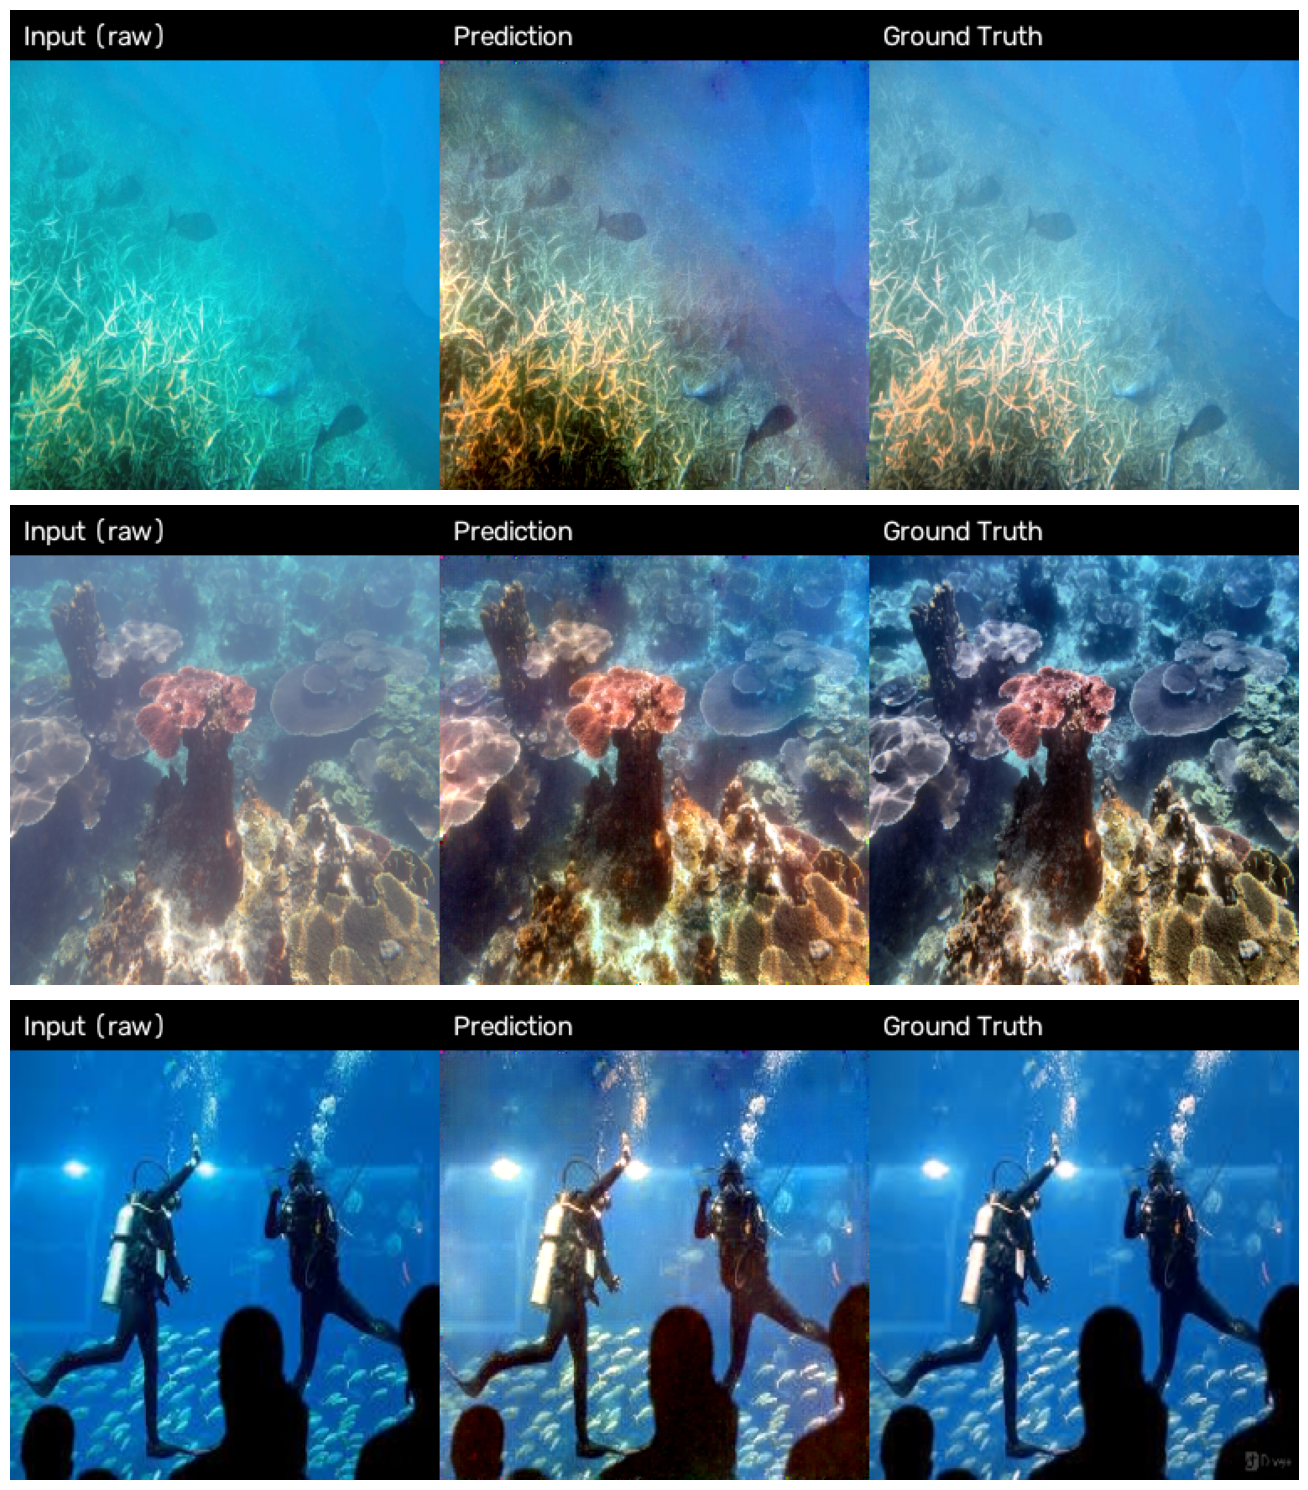

In [16]:
def put_title(image, title):
    """Add a black title bar ABOVE the image (the old version painted over the top 30 px of the image)."""
    bar = np.zeros((30, image.shape[1], 3), dtype=np.uint8)
    cv2.putText(bar, title, (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return np.vstack([bar, image])


def save_bgr(path, rgb):
    cv2.imwrite(str(path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


@torch.no_grad()
def dehaze_image(image_path, size=IMG_SIZE):
    """Run the model on one image; returns input, prediction and the forward-pass time in ms."""
    model.eval()
    with Image.open(image_path) as im:
        rgb = np.array(im.convert("RGB"))
    rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    I = np_to_tensor(rgb).unsqueeze(0).to(DEVICE)

    sync()
    t0 = time.perf_counter()
    pred = wfdiff_infer(model, I)
    sync()
    infer_ms = (time.perf_counter() - t0) * 1000.0

    return {"input": rgb, "prediction": tensor_to_uint8(pred), "infer_ms": infer_ms}


def compare_one(raw_path, ref_path, output_dir):
    stem = Path(raw_path).stem
    o = dehaze_image(raw_path)

    with Image.open(ref_path) as im:
        gt = cv2.resize(np.array(im.convert("RGB")), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    panels = [put_title(o["input"], "Input (raw)"), put_title(o["prediction"], "Prediction"), put_title(gt, "Ground Truth")]

    psnr = peak_signal_noise_ratio(gt, o["prediction"], data_range=255)
    # same SSIM definition as the training code (Gaussian window, sigma=1.5)
    ssim = structural_similarity(gt, o["prediction"], channel_axis=2, data_range=255,
                                 gaussian_weights=True, sigma=1.5, use_sample_covariance=False)
    uiqm = compute_uiqm(o["prediction"])
    print(f"{stem}: PSNR={psnr:.2f} SSIM={ssim:.4f} UIQM(pred)={uiqm:.3f} inference={o['infer_ms']:.1f}ms")

    save_bgr(Path(output_dir) / f"{stem}_input.png", o["input"])
    save_bgr(Path(output_dir) / f"{stem}_prediction.png", o["prediction"])
    save_bgr(Path(output_dir) / f"{stem}_ground_truth.png", gt)
    comparison = np.hstack(panels)
    save_bgr(Path(output_dir) / f"{stem}_comparison.png", comparison)
    return comparison, {"file": Path(raw_path).name, "psnr": psnr, "ssim": ssim, "uiqm": uiqm, "infer_ms": o["infer_ms"]}


N_COMPARE = 5   # number of test images

results = [compare_one(r, g, OUTPUT_DIR) for r, g in test_pairs[:N_COMPARE]]
comparisons = [c for c, _ in results]

comparison_csv = os.path.join(LOG_DIR, "comparison_metrics.csv")
with open(comparison_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file", "psnr", "ssim", "uiqm", "infer_ms"])
    writer.writeheader()
    writer.writerows(m for _, m in results)
print(f"Saved outputs to: {OUTPUT_DIR}\nPer-image metrics saved to {comparison_csv}")

# Display first 3 comparisons
show = comparisons[:3]
if show:
    plt.figure(figsize=(18, 5 * len(show)))
    for i, c in enumerate(show):
        plt.subplot(len(show), 1, i + 1)
        plt.imshow(c)
        plt.axis("off")
    plt.tight_layout()
    plt.show()